# Bayesian Router End-to-End Talk Workbook

This notebook is designed to help you understand the full story of the talk from start to finish.

It is not just a bag of simulations. It follows the exact end-to-end flow you need to explain on stage:

1. why model routing is needed
2. how the composite reward works without human labels
3. how Thompson Sampling makes one routing decision
4. how the router learns over many requests
5. why priors, decay, fallback, shadow evaluation, and circuit breakers matter in production
6. how to talk about contextual routing as future work

## How to use this notebook

- Read the markdown cells first to follow the story.
- Run the code cells in order.
- After each section, pause and make sure you can explain the intuition in your own words.
- Treat this as a study-and-rehearsal notebook, not a benchmark report.

## What you should be able to explain by the end

- why the talk focuses on telemetry instead of human labels
- what `alpha` and `beta` mean intuitively
- why Thompson Sampling balances exploration and exploitation naturally
- why expert priors help with cold start
- why decay helps with provider drift
- how fallback, shadow evaluation, and circuit breakers make the system safer
- what changes if routing becomes contextual

## The Talk Flow in One Page

Here is the entire system as a simple story:

1. A user query arrives.
2. The router keeps a belief about each model using a Beta distribution.
3. It samples one temporary score from each belief and picks the winner.
4. If the winner is not trusted enough, the router can fall back to a safer model.
5. A second model may be evaluated in the background as shadow traffic.
6. The chosen model returns telemetry: validity, latency, retry behavior.
7. A composite reward turns that telemetry into one score in `[0, 1]`.
8. That score updates `alpha` and `beta`.
9. Periodically, decay shrinks old evidence so the router can adapt to drift.
10. Circuit breakers protect the system if one model starts failing repeatedly.
11. Over time, the router shifts more traffic toward the best cost/quality tradeoff.

This notebook mirrors that order.

## Notebook Map

- Part 1: Why routing exists
- Part 2: Composite reward from telemetry
- Part 3: Beta intuition and Thompson Sampling
- Part 4: One request end to end through the real package
- Part 5: Cold start and priors
- Part 6: Decay and model rot
- Part 7: Fallback and shadow evaluation
- Part 8: Circuit breakers
- Part 9: Long-run outcome and cost comparison
- Part 10: Contextual routing as future work

In [84]:
import copy          # used to deep-copy simulator profiles so each run starts fresh
import importlib     # used to force-reload local package modules in notebook kernels
import random        # used alongside numpy for seeding
import sys
from collections import Counter   # used to count model selection frequencies
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
# Fix both numpy and stdlib random so every run produces identical results.
# Remove these two lines if you want to see how randomness affects outputs.
np.random.seed(42)
random.seed(42)


def locate_package_root() -> Path:
    """Find the `model_routing` package root from either repo root or notebooks dir."""
    # Try three candidate directories so the notebook works whether you
    # open it from the repo root, the model_routing/ folder, or the notebooks/ folder.
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for candidate in candidates:
        if (candidate / "bayesian_router").exists():
            return candidate
        if (candidate / "model_routing" / "bayesian_router").exists():
            return candidate / "model_routing"
    raise RuntimeError(
        "Could not locate the bayesian_router package. Run this notebook from the repo root or the notebooks directory."
    )


PACKAGE_ROOT = locate_package_root()
# Insert so Python finds our local package before any globally installed version.
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

# Notebook kernels keep imported modules alive across edits.
# Explicit reloads here make rerunning this setup cell refresh local source files
# such as simulator.py, router.py, and rewards.py without requiring a kernel restart.
import bayesian_router  # noqa: E402
import bayesian_router.types as _types_mod  # noqa: E402
import bayesian_router.rewards as _rewards_mod  # noqa: E402
import bayesian_router.simulator as _simulator_mod  # noqa: E402
import bayesian_router.router as _router_mod  # noqa: E402
import bayesian_router.presets as _presets_mod  # noqa: E402

for _module in (
    _types_mod,
    _rewards_mod,
    _simulator_mod,
    _router_mod,
    _presets_mod,
    bayesian_router,
):
    importlib.reload(_module)

from bayesian_router import (  # noqa: E402
    Router,            # the real production router (Thompson Sampling + all safety layers)
    CompositeReward,   # converts (latency_ms, validity_score, retry_count) -> reward in [0,1]
    ModelSimulator,    # simulates LLM calls and returns telemetry keys matching Router.update()
    DEFAULT_PROFILES,  # SimulationProfile for gpt-4o / gpt-4o-mini / claude-haiku
    EXPERT_PRIORS,     # Beta(alpha, beta) starting beliefs informed by public benchmarks
    UNIFORM_PRIORS,    # Beta(1, 1) — maximum uncertainty, used as a baseline comparison
    ModelConfig,       # data class that holds (alpha, beta, cost_per_1k) for one model
)


# --- tiny display helpers ---
# --- display helpers (no router logic here, just formatting) ---

def format_value(value):
    # Floats -> adaptive precision, None/NaN -> empty string for clean table output.
    # Small cost values like 0.000075 should not round to 0.000 in notebook tables.
    if value is None:
        return ""
    if isinstance(value, float):
        if np.isnan(value):
            return ""
        # Use more precision for very small values so cheap-model costs stay visible.
        if abs(value) < 0.01:
            return f"{value:.6f}"
        return f"{value:.3f}"
    return str(value)


def print_table(rows, columns=None, max_rows=None):
    # Simple text-based table; avoids pandas dependency.
    # `columns` lets callers show only a subset of keys from each row dict.
    rows = rows[:max_rows] if max_rows is not None else rows
    if not rows:
        print("(no rows)")
        return
    if columns is None:
        columns = list(rows[0].keys())   # use all keys from first row by default

    # Compute column widths: at least as wide as the header, at least as wide as any value.
    widths = {col: len(col) for col in columns}
    for row in rows:
        for col in columns:
            widths[col] = max(widths[col], len(format_value(row.get(col))))

    header = " | ".join(f"{col:<{widths[col]}}" for col in columns)
    separator = "-+-".join("-" * widths[col] for col in columns)
    print(header)
    print(separator)
    for row in rows:
        print(" | ".join(f"{format_value(row.get(col)):<{widths[col]}}" for col in columns))


def average(values):
    # Returns NaN instead of crashing on empty lists, which makes downstream
    # summary tables easier to read when a condition is never triggered.
    return sum(values) / len(values) if values else float("nan")


def clone_priors(priors):
    # The Router mutates its internal alpha/beta state during each run.
    # If we passed the same dict twice we would get inconsistent starting states,
    # so every simulation call needs its own fresh ModelConfig objects.
    return {
        name: ModelConfig(alpha=cfg.alpha, beta=cfg.beta, cost_per_1k=cfg.cost_per_1k)
        for name, cfg in priors.items()
    }


def prior_mean(cfg: ModelConfig) -> float:
    # The Beta distribution mean is alpha / (alpha + beta).
    # This is the router's starting confidence before any real traffic.
    return cfg.alpha / (cfg.alpha + cfg.beta)


def cumulative_rate(records, predicate):
    # Computes the running fraction of rows where predicate(row) is True.
    # Example: cumulative fallback rate over time.
    # At query 1 it is 0 or 1. By query N it converges to the overall rate.
    running = []
    hits = 0
    for idx, row in enumerate(records, start=1):
        if predicate(row):
            hits += 1
        running.append(hits / idx)  # fraction up to this query
    return running


def rolling_model_share(records, model_name: str, window: int = 20):
    # Computes what fraction of the last `window` queries went to `model_name`.
    # A rising line means the router is routing more to that model.
    # A falling line means it is moving traffic away.
    shares = []
    for i in range(len(records)):
        window_records = records[max(0, i - window + 1) : i + 1]
        share = sum(1 for row in window_records if row["served_model"] == model_name)
        shares.append(share / len(window_records))
    return shares


def snapshot_rows(state_dict):
    # Converts `router.get_distributions()` output into a list of plain dicts
    # that print_table can display. Called before and after each request to
    # show how the belief changed.
    rows = []
    for name, state in state_dict.items():
        rows.append(
            {
                "model": name,
                "alpha": state.alpha,        # evidence of success (higher = more confident it is good)
                "beta": state.beta,          # evidence of failure (higher = more confident it is bad)
                "confidence": state.confidence,   # = alpha / (alpha + beta)
                "selections": state.selections,
                "shadow_selections": state.shadow_selections,
                "circuit_state": state.circuit_state,    # closed / open / half-open
                "recent_failures": state.recent_failures,
            }
        )
    return rows


# --- telemetry compatibility helpers ---
# These make the notebook robust to either simulator output shape:
# old  -> {is_valid: bool, retried: bool}
# new  -> {validity_score: float, retry_count: int}
# That way the notebook keeps working even if the kernel still has an older import loaded.
def telemetry_validity_score(outcome):
    if "validity_score" in outcome:
        return outcome["validity_score"]
    if "is_valid" in outcome:
        return 1.0 if outcome["is_valid"] else 0.0
    raise KeyError("Telemetry dict has neither 'validity_score' nor 'is_valid'")


def telemetry_retry_count(outcome):
    if "retry_count" in outcome:
        return outcome["retry_count"]
    if "retried" in outcome:
        return 1 if outcome["retried"] else 0
    raise KeyError("Telemetry dict has neither 'retry_count' nor 'retried'")


# --- the two main simulation helpers ---

def run_router_simulation(
    *,
    priors,
    num_queries=100,
    seed=42,
    gamma=0.95,            # decay factor: 0.95 means "keep 95% of old evidence per decay step"
    decay_interval=50,     # apply decay every N queries
    confidence_floor=0.50, # if selected model confidence < this, route to fallback instead
    shadow_rate=0.05,      # fraction of requests that also silently evaluate a second model
    degradation=None,      # optional dict {model, factor, at_query} to simulate provider drift
    circuit_window_size=5,
    circuit_failure_threshold=3,
    circuit_reset_queries=20,
    half_open_max_requests=2,
    fallback_model=None,
    reward_fn=None,        # optional custom CompositeReward for section-specific experiments
    tokens=500,
):
    """Run the real router package end to end with simulated telemetry.

    This is the core simulation helper used by Parts 5-9.
    Each call creates a fresh Router and Simulator so runs are independent.
    If `reward_fn` is provided, that reward definition is used instead of the package default.
    """
    # Seed both RNG libraries to get reproducible results across runs.
    random.seed(seed)
    np.random.seed(seed)

    # deep-copy profiles so degradation applied in one run does not bleed into another.
    simulator = ModelSimulator(profiles=copy.deepcopy(DEFAULT_PROFILES))

    # The real production Router from bayesian_router/router.py.
    # It contains: Thompson Sampling, decay, fallback, shadow evaluation, circuit breakers.
    router = Router(
        models=clone_priors(priors),       # fresh alpha/beta for each run
        reward_fn=reward_fn,
        gamma=gamma,
        decay_interval=decay_interval,
        confidence_floor=confidence_floor,
        shadow_rate=shadow_rate,
        circuit_window_size=circuit_window_size,
        circuit_failure_threshold=circuit_failure_threshold,
        circuit_reset_queries=circuit_reset_queries,
        half_open_max_requests=half_open_max_requests,
        fallback_model=fallback_model,
    )

    records = []
    for query_id in range(num_queries):

        # Optionally degrade a provider at a specific query (simulates model rot).
        if degradation and query_id == degradation["at_query"]:
            simulator.degrade(degradation["model"], degradation["factor"])
            # factor > 1 means: latency * factor, validity / factor

        # Snapshot beliefs BEFORE the request so we can show how they change.
        pre_state = router.get_distributions()

        # Step 1: Thompson Sampling picks a model (may fall back if confidence is low).
        selection = router.select()
        # selection.model         = which model will serve the user
        # selection.shadow_model  = which model (if any) will evaluate silently
        # selection.selection_reason = "thompson" / "confidence_floor" / "circuit_open"
        # selection.fallback_used = True if the confidence floor triggered

        # Step 2: Simulate the primary LLM call → telemetry.
        primary = simulator.call(selection.model, tokens=tokens)
        # Normalize telemetry keys so both old and new simulator outputs work.
        primary_validity_score = telemetry_validity_score(primary)
        primary_retry_count = telemetry_retry_count(primary)

        # Step 3: Compute composite reward and update the selected model's Beta belief.
        # reward.total = 0.50 * validity + 0.30 * latency_score + 0.20 * retry_score
        # alpha += reward.total
        # beta  += (1 - reward.total)
        reward = router.update(
            selection.model,
            latency_ms=primary["latency_ms"],
            validity_score=primary_validity_score,
            retry_count=primary_retry_count,
        )

        # Step 4 (optional): Evaluate the shadow model without serving the user.
        # update_shadow() updates the shadow model's belief but does NOT increment
        # the query counter, so decay timing is unaffected.
        shadow = None
        shadow_reward = None
        if selection.shadow_model:
            shadow = simulator.call(selection.shadow_model, tokens=tokens)
            shadow_validity_score = telemetry_validity_score(shadow)
            shadow_retry_count = telemetry_retry_count(shadow)
            shadow_reward = router.update_shadow(
                selection.shadow_model,
                latency_ms=shadow["latency_ms"],
                validity_score=shadow_validity_score,
                retry_count=shadow_retry_count,
            )

        # Snapshot beliefs AFTER the request so we can compare before vs after.
        post_state = router.get_distributions()

        # Collect everything into one row for analysis.
        row = {
            "query_id": query_id + 1,
            "served_model": selection.model,
            "selection_reason": selection.selection_reason,
            "fallback_used": selection.fallback_used,
            "shadow_model": selection.shadow_model,
            "latency_ms": primary["latency_ms"],
            "validity_score": primary_validity_score,
            "retry_count": primary_retry_count,
            "reward_total": reward.total,      # composite score in [0, 1]
            "reward_validity": reward.validity,
            "reward_latency": reward.latency,
            "reward_retry": reward.retry,
            "primary_cost": primary["cost"],
            "shadow_cost": 0.0 if shadow is None else shadow["cost"],
            "total_cost": primary["cost"] + (0.0 if shadow is None else shadow["cost"]),
            "served_confidence_before": pre_state[selection.model].confidence,
            "served_confidence_after": post_state[selection.model].confidence,
            "shadow_latency_ms": np.nan if shadow is None else shadow["latency_ms"],
            "shadow_validity_score": np.nan if shadow is None else telemetry_validity_score(shadow),
            "shadow_retry_count": np.nan if shadow is None else telemetry_retry_count(shadow),
            "shadow_reward_total": np.nan if shadow_reward is None else shadow_reward.total,
        }

        # Also store per-model alpha/beta/confidence for post-hoc analysis.
        for model_name, state in post_state.items():
            safe_name = model_name.replace("-", "_")   # gpt-4o -> gpt_4o
            row[f"{safe_name}_alpha"] = state.alpha
            row[f"{safe_name}_beta"] = state.beta
            row[f"{safe_name}_confidence"] = state.confidence
            row[f"{safe_name}_circuit"] = state.circuit_state

        records.append(row)

    return router, records   # return router for state inspection; records for plotting


def run_fixed_policy(
    model_name,
    *,
    num_queries=100,
    seed=42,
    degradation=None,
    tokens=500,
):
    """Baseline: always choose the same model. Used for cost comparison in Part 9.

    This intentionally has NO routing logic. It just calls one model for every
    query and records what happened. This is the 'always gpt-4o' or 'always
    gpt-4o-mini' baseline we compare the router against.
    """
    random.seed(seed)
    np.random.seed(seed)

    simulator = ModelSimulator(profiles=copy.deepcopy(DEFAULT_PROFILES))
    reward_fn = CompositeReward()    # used only for reporting, not for learning
    records = []

    for query_id in range(num_queries):
        if degradation and query_id == degradation["at_query"]:
            simulator.degrade(degradation["model"], degradation["factor"])

        # No select() call here. Always the same model.
        outcome = simulator.call(model_name, tokens=tokens)
        validity_score = telemetry_validity_score(outcome)
        retry_count = telemetry_retry_count(outcome)

        # Compute reward for fair comparison, but nothing updates with it.
        reward = reward_fn.compute(
            latency_ms=outcome["latency_ms"],
            validity_score=validity_score,
            retry_count=retry_count,
        )
        records.append(
            {
                "query_id": query_id + 1,
                "served_model": model_name,
                "latency_ms": outcome["latency_ms"],
                "validity_score": validity_score,
                "retry_count": retry_count,
                "reward_total": reward.total,
                "cost": outcome["cost"],
            }
        )

    return records


print(f"Imported bayesian_router from: {PACKAGE_ROOT}")

Imported bayesian_router from: /Users/smahishi/Documents/micro_saas/model_routing


## Part 1: Why Model Routing Exists

The talk starts with a practical business problem.

If you always choose the strongest model:
- quality stays high
- but cost is unnecessarily high
- and latency is often higher than it needs to be

If you always choose the cheapest model:
- cost drops
- but quality and reliability can suffer

So the real question is not:
> Which one model is best?

It is:
> Which model is the best tradeoff for this request, right now?

The package ships with three built-in simulation profiles that match the story in the talk:
- `gpt-4o`: strongest but expensive and slower
- `gpt-4o-mini`: cheapest and fast, but somewhat weaker
- `claude-haiku`: also cheap and fast, with a different quality/latency profile

The next cell prints those profiles and shows why neither "always strongest" nor "always cheapest" is the right default.

---
### 💬 Say this on stage — Part 1

**Opening line to use:**
> "Most teams using LLMs make one of three choices: always use the strongest model, hardcode a rule like 'use GPT-4 for everything important', or manually pick one and hope it stays good enough. All three break down for the same reason: they are static decisions in a dynamic environment."

**On the cost chart:**
> "Look at the cost column. gpt-4o costs about 33 times more per request than gpt-4o-mini. Not 10% more. 33 times more. If even 30% of your queries could be handled correctly by a smaller model, the savings are significant."

**On the validity chart:**
> "But look at the validity column. gpt-4o has a 96% validity rate. gpt-4o-mini is at 89%. That 7-point gap is real. For some queries, the cheaper model fails more often, and those failures have real costs — retries, downstream errors, degraded user experience."

**The tension to set up:**
> "So the question is not 'which model is best.' It is 'which model is best for this request, right now, given current provider quality, given my latency budget, given my cost constraints.' That is what the router learns to answer."

**One-sentence version for any Q&A card:**
> "The router solves the cost-quality tradeoff dynamically instead of asking you to hardcode a static answer."

Default simulation profiles used in the package:

model        | cost_per_500_tokens | base_validity | avg_latency_ms | retry_rate
-------------+---------------------+---------------+----------------+-----------
gpt-4o       | 0.002500            | 0.960         | 2500.000       | 0.040     
gpt-4o-mini  | 0.000075            | 0.890         | 800.000        | 0.090     
claude-haiku | 0.000125            | 0.910         | 600.000        | 0.070     


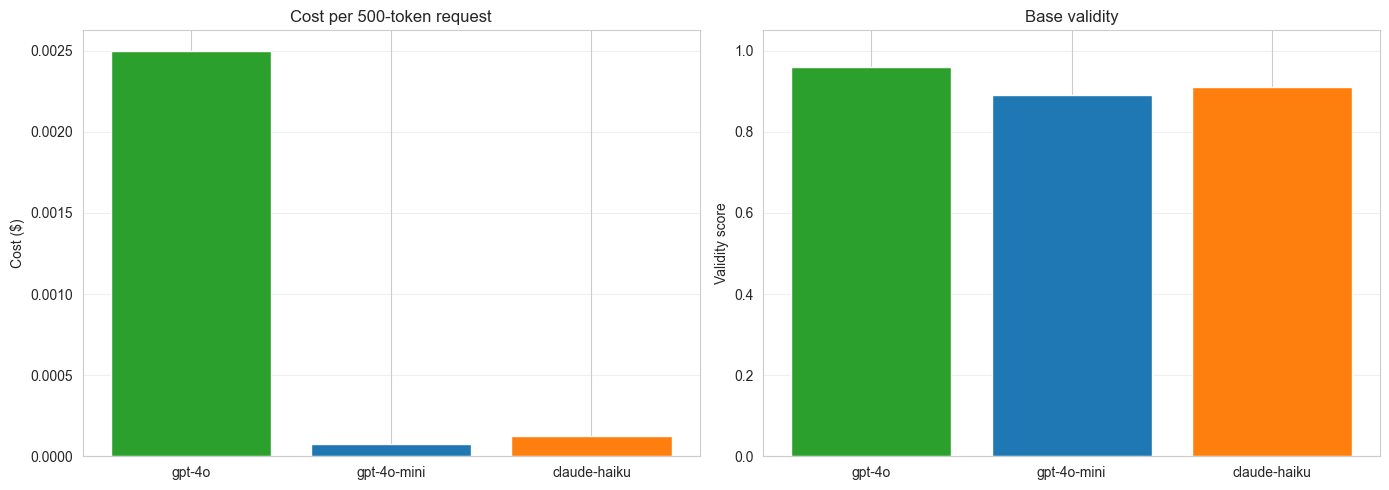

Talk intuition:
- `gpt-4o` is strongest, but also slowest and most expensive.
- `gpt-4o-mini` is extremely cheap and fast, but weaker on average.
- `claude-haiku` is also cheap and fast, with a slightly different tradeoff.
- A router exists because the best choice depends on the cost/quality tradeoff, not just one metric.


In [85]:
# DEFAULT_PROFILES holds SimulationProfile objects for each model.
# Each profile has: cost_per_1k, base_validity, latency_range, retry_rate.
# We derive a single cost-per-request by assuming a 500-token query (a realistic average).
profile_rows = []
for name, profile in DEFAULT_PROFILES.items():
    avg_latency = sum(profile.latency_range) / 2          # midpoint of the latency range
    cost_per_request = (500 / 1000) * profile.cost_per_1k # cost_per_1k is per 1000 tokens
    profile_rows.append(
        {
            "model": name,
            "cost_per_500_tokens": cost_per_request,
            "base_validity": profile.base_validity,   # probability that one call succeeds
            "avg_latency_ms": avg_latency,
            "retry_rate": profile.retry_rate,         # probability of needing one retry
        }
    )

print("Default simulation profiles used in the package:\n")
print_table(profile_rows)

# --- Left chart: cost ---
# This is the core motivation for routing. The cost gap is huge.
# gpt-4o is ~33x more expensive per request than gpt-4o-mini.
# If we can route even 30-40% of traffic to cheap models without quality loss,
# total cost drops significantly.

# --- Right chart: validity ---
# This shows the quality cost of always using cheap models.
# gpt-4o has 96% base validity; gpt-4o-mini has 89%.
# The 7-point gap means cheaper models fail more often on harder queries.
# This is the tension the router must navigate.

models = [row["model"] for row in profile_rows]
costs = [row["cost_per_500_tokens"] for row in profile_rows]
validities = [row["base_validity"] for row in profile_rows]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(models, costs, color=["tab:green", "tab:blue", "tab:orange"])
axes[0].set_title("Cost per 500-token request")
axes[0].set_ylabel("Cost ($)")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(models, validities, color=["tab:green", "tab:blue", "tab:orange"])
axes[1].set_title("Base validity")
axes[1].set_ylabel("Validity score")
axes[1].set_ylim(0.0, 1.05)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Talk intuition:")
print("- `gpt-4o` is strongest, but also slowest and most expensive.")
print("- `gpt-4o-mini` is extremely cheap and fast, but weaker on average.")
print("- `claude-haiku` is also cheap and fast, with a slightly different tradeoff.")
print("- A router exists because the best choice depends on the cost/quality tradeoff, not just one metric.")

## Part 2: Composite Reward Without Human Labels

This is the core idea of the talk.

Academic routing papers often assume someone labels every response as good or bad.
In production, that usually does not happen.

So instead of asking humans to score every answer, the router builds a reward from signals it already has:

- **validity**: did the output pass validation?
- **latency**: was it fast enough?
- **retry**: did the agent need to self-correct?

Those are combined into one continuous score in `[0, 1]`.

In the current package the weights are:

```text
reward = 0.50 * validity
       + 0.30 * latency_score
       + 0.20 * retry_score
```

Important nuance:
- `validity_score` is continuous in `[0, 1]`, so partial credit is possible
- `retry_count` is graduated, so one retry is not treated the same as three retries
- latency is scored by a sigmoid curve, not a hard cutoff

### Why only latency uses a sigmoid

This is an easy thing to miss, so it is worth making explicit.

- **Latency** is a raw physical measurement in milliseconds.
  Its meaning is naturally non-linear around an SLA threshold.
  Example: 1900ms and 2100ms should be treated as very similar, not as total opposites.

  Why is a sigmoid useful here?

  - If we used a **hard cutoff**, then 1999ms and 2001ms would be treated as fundamentally different, even though they are almost the same user experience.
  - If we used a **pure linear penalty** over all latencies, then very fast and very slow responses would keep changing reward at the same rate everywhere, which is usually not what we want.
  - In real systems, we care most about the region around the SLA boundary. That is where decisions feel meaningful: "slightly fast enough", "slightly too slow", and "clearly too slow".

  A sigmoid gives us exactly that shape:

  - very fast responses get close to full latency credit
  - responses near the SLA threshold change reward gradually, not abruptly
  - extremely slow responses are strongly penalised, but the penalty eventually saturates instead of growing forever

  That makes the reward signal much more stable for learning.
  A 50ms wobble around the threshold should not completely flip the router's judgment.
  The sigmoid prevents that kind of brittle behaviour.

  A simple way to think about it is:

  - 1000ms vs 1200ms -> both are comfortably fast, so reward should be similar
  - 1900ms vs 2100ms -> this is the sensitive region, so reward should change, but smoothly
  - 4000ms vs 5000ms -> both are already clearly slow, so we do not need huge additional penalty differences

  So the sigmoid is required here because it matches how latency actually matters in practice: smooth around the SLA boundary, forgiving for small fluctuations, and strongly but not infinitely punishing for very slow responses.

- **Validity** is different.
  `validity_score` is already a meaningfully normalised number chosen by the caller.
  If the caller says `validity_score = 0.6`, they are already saying "this output deserves about 60% of the validity credit." 
  A linear mapping respects that meaning.

- **Retry** is also different.
  `retry_count` is a small discrete integer from the orchestration layer, not a continuous physical measurement.
  A simple graduated penalty is easier to understand and explain:
  - 0 retries -> full retry credit
  - 1 retry -> about two-thirds credit
  - 2 retries -> about one-third credit
  - 3 or more retries -> no retry credit

So the design choice is:
- sigmoid for **latency**, because latency is continuous and needs a smooth threshold
- linear / graduated rules for **validity** and **retry**, because those inputs already carry the meaning we want

### Where `validity_score` comes from

The GPT API does **not** return a built-in `validity_score`.
The model returns an output, and **your application computes the validity score after the call**.

So the flow is:

1. the model returns text / JSON / tool arguments / code
2. your application checks whether that output is usable
3. your application converts that result into a number in `[0, 1]`
4. that number becomes `validity_score`

In other words, `validity_score` comes from **your validator, parser, tests, business rules, or judge**, not from the API itself.

Common ways to define it:

- **Structured JSON tasks**
  - `1.0` if the output parses and passes schema validation
  - `0.0` if it fails

- **Extraction tasks**
  - use something like `fields_found / fields_expected`
  - example: 3 out of 4 required fields -> `0.75`

- **Code / SQL generation**
  - `1.0` if it runs and passes tests
  - partial credit if some tests pass
  - `0.0` for syntax or execution failure

- **Tool-calling agents**
  - `1.0` if the tool arguments are valid and the step succeeds
  - lower scores if arguments are malformed or output is incomplete

- **Open-ended text tasks**
  - use a rubric or an LLM judge to produce a score in `[0, 1]`

A good practical rule is:

> `validity_score` should answer: "How usable was this output for my application?"

Very important design principle:
- `validity_score` should capture **correctness / usability**
- `latency_ms` should capture **speed**
- `retry_count` should capture **extra attempts**

Try not to mix them too much.
For example, if an output is correct but took one retry, you may still want:
- `validity_score = 1.0`
- `retry_count = 1`

That way the retry penalty comes from the retry signal, not from lowering validity and double-penalizing the same issue.

If you are starting from scratch, the easiest and strongest option is binary validity:
- pass -> `1.0`
- fail -> `0.0`

Then, once your validator is reliable, you can move to partial credit.

### What `retry` means here

In this project, `retry` does **not** mean the model provider silently retried inside its own API.
It means **your application or agent asked the model again because the first output was not usable**.

Common examples:
- the model was supposed to return JSON, but the JSON did not parse
- a required field was missing, so the validator failed
- tool arguments were malformed, so the agent tried again
- the first answer was incomplete, and the agent ran a self-correction loop

How do we know whether a retry happened?
- from the orchestration layer in your own code
- from the validator or parser
- from the agent loop that tracks how many attempts were needed before success

So `retry_count` is really a proxy for:
- reliability
- hidden extra latency
- hidden extra cost
- extra agent effort to get a usable result

That is why the reward penalizes it: even if the final answer is eventually correct, a model that often needs retries is less reliable than one that gets it right on the first try.

The next cell shows exactly how the package computes that reward.

---
### 💬 Say this on stage — Part 2

**Opening the no-human-labels point:**
> "Here is the thing that most routing papers skip. They assume you have labeled data. Someone rated every response good or bad. In production, that almost never happens. Nobody is manually grading 10,000 LLM responses a day."

**How labels are usually used in routing:**
> "In a labeled routing setup, you first collect a dataset of prompts. Then you run two or more models on each prompt. A human either gives each answer a label like good or bad, or says which answer they prefer. Once you have those labels, you train a classifier or scoring model that predicts whether the cheap model is good enough for a new prompt. At runtime, the router uses that predicted score to decide whether to stay with the cheap model or escalate to the strong one."

**Concrete example you can say out loud:**
> "Imagine 5,000 customer-support prompts. You run both GPT-4o-mini and GPT-4o on each one. A human reviewer marks whether the mini model's answer was acceptable. Then you train a router that predicts, from the prompt alone, whether GPT-4o-mini is likely to be acceptable. If the score is high, route to the mini model. If it is low, route to GPT-4o. That works well if you can afford the labeling pipeline."

**Why this project does not rely on that:**
> "The problem is that labeled routing turns model routing into a supervised-data problem. You need people, review time, quality control, and periodic relabeling whenever the provider changes behavior. That is exactly the operational burden we are trying to avoid."

**On the three signals:**
> "So we ask: what signals does a production system already have? Almost every agent pipeline has three: did the output parse? How fast was it? Did we need to retry? You are already logging these things. The composite reward is just a weighted combination of what you already have."

**If someone asks, 'does the GPT API give you a validity score?':**
> "No. The API gives you the raw output. We compute `validity_score` ourselves after the call. For a structured-output task, that may be as simple as: did the JSON parse and pass the schema? If yes, `1.0`. If not, `0.0`. For extraction tasks it can be partial credit, like 3 fields found out of 4 giving `0.75`. For code generation it might be based on test pass rate. The key point is: validity is application-defined, not provider-defined."

**Best simple example to say out loud:**
> "Suppose I ask the model for JSON with `name`, `email`, and `country`. If the JSON parses and all required fields are present, validity is `1.0`. If the JSON parses but `email` is missing, maybe validity is `0.67`. If the JSON does not parse at all, validity is `0.0`. That score is what we feed into the router."

**Important design principle:**
> "Try to keep the signals separate. Validity should mean correctness or usability. Retry should mean how many extra attempts were needed. Latency should mean speed. If the answer is correct but needed one retry, you may still want validity to be `1.0` and let the retry penalty come from the retry signal. Otherwise you double-count the same problem."

**What `retry` means in this talk:**
> "Retry here does not mean the provider retried internally. It means our own application or agent had to ask the model again because the first answer was not usable. Maybe the JSON did not parse. Maybe a required field was missing. Maybe the tool arguments were malformed. The important point is that we know this from our orchestration layer and validator, not from the model magically telling us."

**Concrete retry example you can say out loud:**
> "Suppose the model is asked for structured JSON. On attempt one it returns invalid JSON, so the parser fails. The agent sends a repair prompt, attempt two succeeds. That second call is a retry. Even though the final output is correct, it was slower, more expensive, and less reliable than a model that got it right on the first try."

**Pointing at the reward table:**
> "Look at the rows. A perfect fast response scores 0.96. A valid but slow one scores 0.72. A response that failed and retried scores 0.02. The router sees this spread and uses it to form a preference. That preference is the learning signal. No human needed."

**On the latency sigmoid:**
> "The latency scoring is a sigmoid curve, not a hard cutoff. That matters. If your SLA is 2000ms, a 2100ms response is not a hard failure. It gets slightly less credit. A 1900ms response gets slightly more. That smoothness is what makes the reward useful as a training signal rather than just a boolean flag."

**If someone asks, 'why not use sigmoid for validity and retry too?':**
> "Because latency is a raw physical measurement, so it makes sense to smooth it around a threshold. Validity is already a score in 0 to 1 chosen by the caller. If I say the output deserves 0.6 validity, I usually mean exactly 60% of the validity credit, so a linear mapping is the honest thing to do. Retry is a small discrete count, not a continuous measurement, so a simple graduated penalty is easier to reason about and easier to explain."

**On the graduated retry penalty:**
> "One retry costs you about a third of the retry credit. Two retries costs you two thirds. Three or more retries gives zero retry credit. The router learns to avoid models that need retries, not because we told it to, but because retries reliably reduce the reward."

**One-sentence version for any Q&A card:**
> "The composite reward converts telemetry the system already collects into a learning signal, without any human labeling step."

Composite reward breakdown for representative telemetry:

scenario                     | latency_ms | validity_score | retry_count | validity_component | latency_component | retry_component | total_reward
-----------------------------+------------+----------------+-------------+--------------------+-------------------+-----------------+-------------
Perfect response             | 700        | 1.000          | 0           | 0.500              | 0.269             | 0.200           | 0.969       
Valid but slow               | 3200       | 1.000          | 0           | 0.500              | 0.036             | 0.200           | 0.736       
Partially correct, one retry | 1600       | 0.600          | 1           | 0.300              | 0.198             | 0.133           | 0.632       
Broken output, many retries  | 3200       | 0.000000       | 3           | 0.000000           | 0.036             | 0.000000        | 0.036       


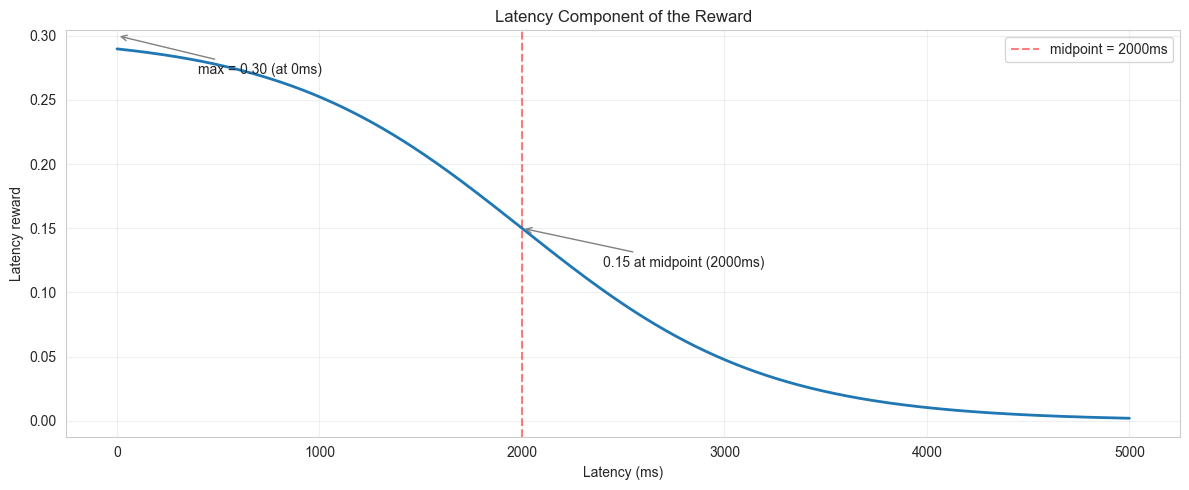

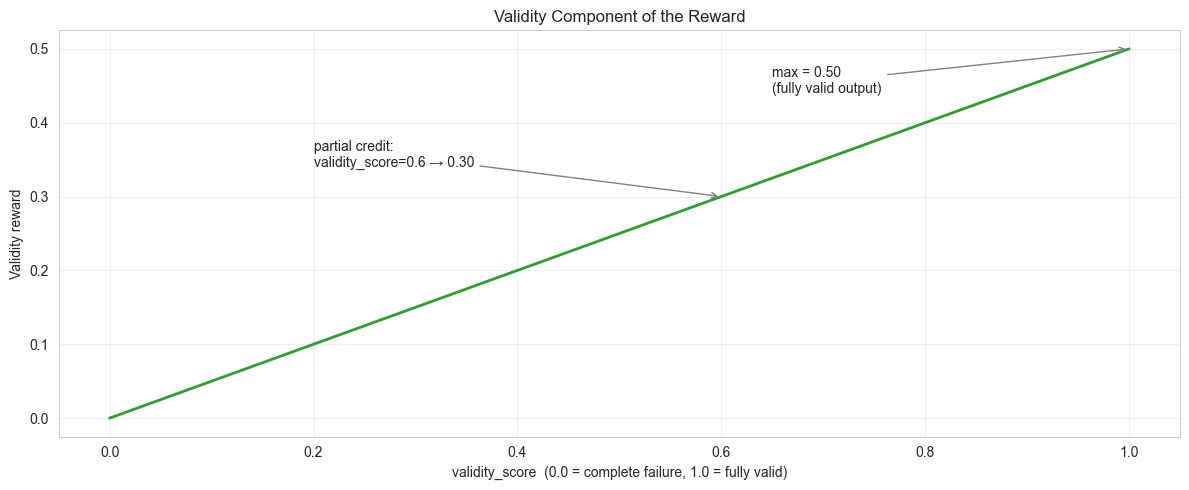

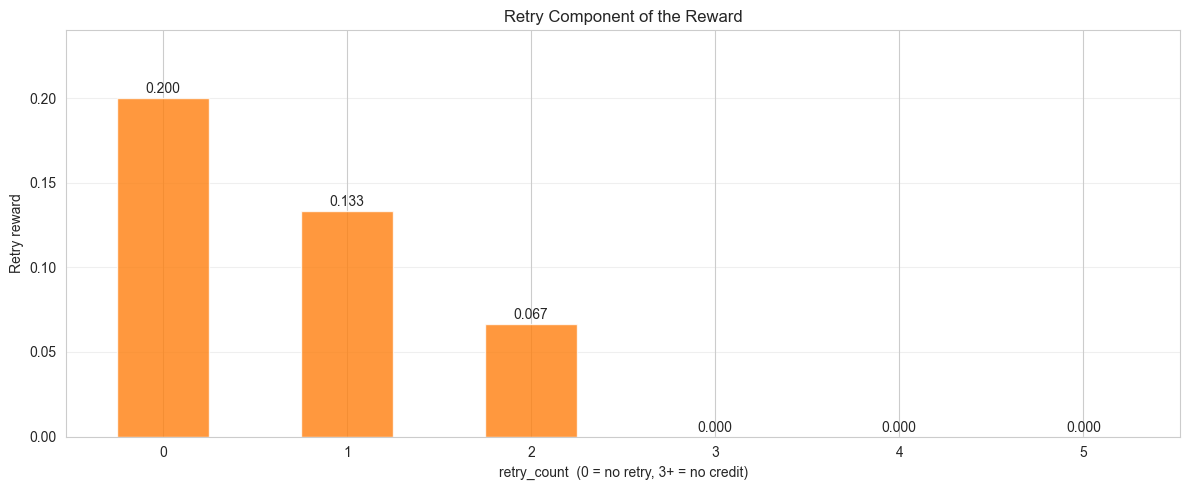


Effect of retry count on reward:

retry_count | retry_component | total_reward_if_other_signals_good
------------+-----------------+-----------------------------------
0           | 0.200           | 0.952                             
1           | 0.133           | 0.886                             
2           | 0.067           | 0.819                             
3           | 0.000000        | 0.752                             
4           | 0.000000        | 0.752                             
Intuition:
- The router does not need a human to say 'good' or 'bad'.
- It observes telemetry, converts it into a score, and learns from that score.
- This is what makes the approach production-friendly.


In [86]:
# CompositeReward uses default weights: validity=0.50, latency=0.30, retry=0.20.
# You can pass custom weights when constructing it for cost-aggressive or quality-first configs.
reward_fn = CompositeReward()

# Four scenarios represent the full range of production telemetry you would observe.
# The router never sees the "scenario" label; it only sees the three numbers.
telemetry_examples = [
    {"scenario": "Perfect response",               "latency_ms": 700,  "validity_score": 1.0, "retry_count": 0},
    {"scenario": "Valid but slow",                 "latency_ms": 3200, "validity_score": 1.0, "retry_count": 0},
    {"scenario": "Partially correct, one retry",  "latency_ms": 1600, "validity_score": 0.6, "retry_count": 1},
    {"scenario": "Broken output, many retries",   "latency_ms": 3200, "validity_score": 0.0, "retry_count": 3},
]

reward_rows = []
for example in telemetry_examples:
    # reward_fn.compute() is the only non-trivial computation here.
    # Internally it does:
    #   validity_component = validity_weight * validity_score
    #   latency_component  = latency_weight / (1 + exp((latency_ms - 2000) / 600))
    #   retry_component    = retry_weight * max(0, 1 - retry_count / 3)
    #   total              = sum of the three
    result = reward_fn.compute(
        latency_ms=example["latency_ms"],
        validity_score=example["validity_score"],
        retry_count=example["retry_count"],
    )
    reward_rows.append(
        {
            "scenario": example["scenario"],
            "latency_ms": example["latency_ms"],
            "validity_score": example["validity_score"],   # 0.0 = hard fail, 1.0 = full pass
            "retry_count": example["retry_count"],         # 0 = no retry, 3+ = no retry credit
            "validity_component": result.validity,         # at most 0.50
            "latency_component": result.latency,           # at most 0.30
            "retry_component": result.retry,               # at most 0.20
            "total_reward": result.total,                  # sum, always in [0, 1]
        }
    )

print("Composite reward breakdown for representative telemetry:\n")
print_table(reward_rows)

# ====================================================================
# GRAPH 1: Latency — sigmoid curve
# ====================================================================
# The sigmoid shape is why latency scoring is smooth, not a hard cutoff.
# At 2000ms the reward is exactly 50% of the max latency component.
# Responses faster than 2000ms get increasingly more credit; slower ones get less.
# This means a 2100ms response is only slightly penalised, not treated as a failure.
latencies = np.linspace(0, 5000, 400)
# Set validity=0 and retry_count=3 so the latency component is the only non-zero part.
latency_rewards = [reward_fn.compute(latency_ms=l, validity_score=0.0, retry_count=3).latency for l in latencies]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(latencies, latency_rewards, linewidth=2, color="tab:blue")
ax.axvline(2000, color="red", linestyle="--", alpha=0.5, label="midpoint = 2000ms")
ax.set_title("Latency Component of the Reward")
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Latency reward")
ax.annotate("max = 0.30 (at 0ms)", xy=(0, reward_fn.latency_weight), xytext=(400, 0.27),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10)
ax.annotate("0.15 at midpoint (2000ms)", xy=(2000, reward_fn.latency_weight / 2), xytext=(2400, 0.12),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ====================================================================
# GRAPH 2: Validity — linear curve
# ====================================================================
# Validity is simply linear: validity_component = 0.50 * validity_score
# A score of 0.0 (complete failure) gives 0.0 component credit.
# A score of 1.0 (perfect output) gives 0.50 component credit.
# A score of 0.6 (partially correct) gives 0.30 component credit.
# This linear mapping means partial quality gets proportional partial reward.
# We fix latency=0ms and retry_count=3 so the validity component is the only non-zero part.
validity_scores = np.linspace(0.0, 1.0, 200)
validity_rewards = [reward_fn.compute(latency_ms=0, validity_score=v, retry_count=3).validity for v in validity_scores]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(validity_scores, validity_rewards, linewidth=2, color="tab:green")
ax.set_title("Validity Component of the Reward")
ax.set_xlabel("validity_score  (0.0 = complete failure, 1.0 = fully valid)")
ax.set_ylabel("Validity reward")
ax.annotate("max = 0.50\n(fully valid output)", xy=(1.0, 0.50), xytext=(0.65, 0.44),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10)
ax.annotate("partial credit:\nvalidity_score=0.6 → 0.30", xy=(0.6, 0.30), xytext=(0.2, 0.34),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ====================================================================
# GRAPH 3: Retry — graduated step-down curve
# ====================================================================
# retry_count=0 gets full credit (0.20).
# retry_count=1 gets 2/3 credit (~0.13).
# retry_count=2 gets 1/3 credit (~0.07).
# retry_count>=3 gets zero credit.
# Formula: max(0, 1 - retry_count / 3) * retry_weight
# The curve steps down linearly from 0 to 3, then is flat at 0 for 3+.
# We fix latency=0ms and validity=0.0 so only the retry component shows.
retry_counts = list(range(6))  # 0, 1, 2, 3, 4, 5
retry_components = [reward_fn.compute(latency_ms=0, validity_score=0.0, retry_count=rc).retry for rc in retry_counts]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(retry_counts, retry_components, color="tab:orange", alpha=0.8, width=0.5)
for rc, rc_val in zip(retry_counts, retry_components):
    ax.text(rc, rc_val + 0.003, f"{rc_val:.3f}", ha="center", fontsize=10)
ax.set_title("Retry Component of the Reward")
ax.set_xlabel("retry_count  (0 = no retry, 3+ = no credit)")
ax.set_ylabel("Retry reward")
ax.set_xticks(retry_counts)
ax.set_ylim(0, 0.24)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Retry penalty table (same data in text form) ---
# retry_count=0 gets full credit (0.20).
# retry_count=1 gets 2/3 credit (0.133).
# retry_count=2 gets 1/3 credit (0.067).
# retry_count>=3 gets zero credit.
# Formula: max(0, 1 - retry_count / 3) * retry_weight
# We fix latency=1000ms and validity=1.0 so only the retry component changes.
retry_rows = []
for retry_count in [0, 1, 2, 3, 4]:
    result = reward_fn.compute(latency_ms=1000, validity_score=1.0, retry_count=retry_count)
    retry_rows.append(
        {
            "retry_count": retry_count,
            "retry_component": result.retry,
            "total_reward_if_other_signals_good": result.total,
        }
    )

print("\nEffect of retry count on reward:\n")
print_table(retry_rows)

print("Intuition:")
print("- The router does not need a human to say 'good' or 'bad'.")
print("- It observes telemetry, converts it into a score, and learns from that score.")
print("- This is what makes the approach production-friendly.")

## Part 3: Beta Intuition and Thompson Sampling

Now that we have a reward, we need a decision rule.

The router keeps one Beta distribution per model.

Very simple interpretation:
- `alpha` = evidence this model tends to do well
- `beta` = evidence this model tends to do poorly
- `confidence ~= alpha / (alpha + beta)`

Why use a distribution instead of just one average?
Because a distribution captures both:
- the current best guess
- how uncertain we still are

That uncertainty is what drives exploration.

### What `gpt4o_quality ~ Beta(8, 3)` means

This notation means:

- `gpt4o_quality` is the unknown quality of the model
- we currently believe that unknown quality follows a **Beta distribution** with parameters `alpha = 8` and `beta = 3`

The important idea is that **`alpha` and `beta` are enough to define the whole distribution**.
We do not need to calculate a separate table of probabilities by hand.
Once we know `alpha` and `beta`, the distribution is fully specified.

You can think of `Beta(8, 3)` as a curve over all possible quality values between `0` and `1`:

- x-axis = possible model quality
- y-axis = how plausible each quality value currently seems

Very simple intuition:

- the center of the belief is roughly the mean
- `mean = alpha / (alpha + beta)`
- so for `Beta(8, 3)`, the mean is `8 / 11 = 0.727`

That means the router's best current guess is that `gpt-4o` has quality around `0.73`.

Also:

- `alpha + beta = 11` is the total amount of evidence
- larger totals make the curve narrower
- smaller totals make the curve wider

So:

- `Beta(8, 3)` and `Beta(80, 30)` have the **same mean**
- but `Beta(80, 30)` is much **narrower**, so the router is much more confident

### How do we sample a value from that distribution?

Once the router has `alpha` and `beta`, it asks NumPy for one random draw:

```python
np.random.beta(8, 3)
```

That one draw might be:

- `0.69` on one request
- `0.81` on another request
- `0.74` on another request

All of those are plausible samples from the same `Beta(8, 3)` belief.

### Where do values like `0.65`, `0.72`, or `0.80` come from?

They are **random samples** drawn from the `Beta(8, 3)` curve.
They are not fixed numbers that we calculate directly from `8` and `3`.

The roles are different:

- `8` and `3` define the **shape** of the distribution
- the **mean** of that distribution is `8 / 11 = 0.727`
- a sampler then draws one random value from that shape

So:

- `0.727` is the center of the belief
- `0.65`, `0.72`, and `0.80` are possible draws around that center

Why are those numbers usually somewhere around `0.7`?
Because the `Beta(8, 3)` curve puts most of its probability mass on the right-hand side of `[0, 1]`.
That makes values near `0.7` much more likely than values near `0.1`.

A compact way to say it is:

> `Beta(8, 3)` defines the curve; `np.random.beta(8, 3)` picks one random point from that curve.

### Optional under-the-hood detail: Gamma distributions

If you want to know how a Beta sample can be generated computationally, one common construction is:

- draw `X ~ Gamma(alpha, 1)`
- draw `Y ~ Gamma(beta, 1)`
- return

```text
X / (X + Y)
```

That ratio is a Beta-distributed sample.

So for `Beta(8, 3)`, one way to think about sampling is:

- draw `X ~ Gamma(8, 1)`
- draw `Y ~ Gamma(3, 1)`
- compute `X / (X + Y)`

That final value might be `0.65`, `0.72`, or `0.80`.

Important note:
- you do **not** need to do this manually in the router
- NumPy handles the sampling for you with `np.random.beta(alpha, beta)`
- this Gamma-ratio picture is just helpful for understanding where the sample comes from under the hood

So when the router samples one value per model, it is not using the mean directly.
It is drawing one temporary score from each model's current belief distribution.

This is the key to exploration:

- strong models usually sample high
- uncertain models sometimes sample surprisingly high
- that is why cheaper or less-tested models still occasionally win a request

### Important note for this project

In textbook Thompson Sampling, Beta distributions are the exact Bayesian match for **binary** rewards.
In this project, the reward is continuous in `[0, 1]`, and we still update:

- `alpha += reward`
- `beta += 1 - reward`

So this is best understood as a **pragmatic Bayesian-style belief model** inspired by the textbook Beta-Bernoulli case.
It is still very useful in practice, but it is slightly more general than the exact theorem case.

### Thompson Sampling in plain English

For each request:
1. sample one temporary value from each model's Beta distribution
2. choose the model with the highest sampled value
3. observe the reward
4. update `alpha` and `beta`

Key intuition:
- a well-performing model usually samples high
- an uncertain model has a wider distribution, so it sometimes samples high too
- that means exploration happens automatically, without a hand-written rule like "explore 10% of the time"

The next cell shows the expert priors and then runs a few sample rounds so you can see this randomness directly.

---
### 💬 Say this on stage — Part 3

**Opening the Beta explanation:**
> "Here is the piece of Bayesian math you actually need to understand. Each model has a Beta distribution. You do not need to know the equation. You need two things: what alpha and beta mean, and why we sample from the distribution instead of just using the average."

**On alpha and beta:**
> "Think of alpha as the count of good outcomes and beta as the count of bad outcomes. If alpha is 8 and beta is 3, the router has seen 11 effective observations and most of them were good. Confidence is roughly 8 divided by 11, which is about 73%."

**If someone asks, 'how do you get a distribution from alpha and beta?':**
> "The answer is: alpha and beta are the parameters of the Beta distribution. Once you say Beta(8,3), the whole curve is defined. You do not build a separate lookup table. The math object is already fully specified by those two numbers. Then the code simply asks NumPy for one random draw from that curve with `np.random.beta(8, 3)`."

**If someone asks, 'where do values like 0.65 or 0.80 come from?':**
> "Those are just random samples from that Beta curve. The numbers 8 and 3 define the shape. The mean is about 0.73, but each request gets one random draw around that center. So 0.65, 0.72, or 0.80 are all plausible samples from the same belief."

**If someone asks, 'what is happening under the hood when you sample from Beta(8,3)?':**
> "One useful mental model is the Gamma-ratio construction. Draw one value from Gamma(8,1), draw one from Gamma(3,1), then divide the first by the sum of both. That ratio is a Beta(8,3) sample. In practice we never do that by hand — we just call `np.random.beta(8, 3)` — but it explains where the random number comes from computationally."

**On why we sample instead of using the mean:**
> "If we just used the mean every time, the router would always pick the same model — whichever had the highest mean. It would never explore. By sampling from the full distribution, a model that is uncertain gets a wider curve. Sometimes that curve produces a high sample, even if its mean is lower. That is how exploration happens. It is proportional to uncertainty. Not random. Not fixed at 10%."

**Pointing at the KDE plot, in simpler terms:**
> "Read the picture like this: a curve further to the right means the router currently believes that model is better. A wider curve means the router is still unsure. A narrower curve means it is more confident. So early on, the cheaper models may still have wide curves that overlap with gpt-4o. That overlap means they can still occasionally produce the highest sample and win a request. That is exploration. Later, after more evidence, the curves become narrower. If gpt-4o is truly better, its curve stays to the right and the cheaper models stop winning very often."

**Why exploration slows down automatically as uncertainty decreases:**
> "This is the nice property of Thompson Sampling. Early on, alpha and beta are small, so the Beta curves are wide. Wide curves mean more overlap, and more overlap means more chances for a weaker but uncertain model to sample unusually high and get tried. After many requests, alpha plus beta becomes large, so the curves get narrow. Narrow curves mean less overlap. Less overlap means the weaker model almost never beats the stronger one by chance. So exploration fades naturally as the router becomes more certain. We do not have to tell it to explore 10% of the time forever."

**Tiny example you can say out loud:**
> "Early on, suppose gpt-4o is around Beta(8,3) and gpt-4o-mini is around Beta(5,4). Their curves still overlap, so mini might occasionally win a request. But after lots of data, you might be closer to Beta(180,60) versus Beta(110,90). The means are similar to before, but the curves are much tighter. At that point the weaker model almost never jumps above the stronger one by luck, so exploration has basically slowed itself down."

**Handling the 'why Thompson Sampling and not something else?' question:**
> "UCB and epsilon-greedy both work. Thompson Sampling has two practical advantages: it incorporates priors naturally, and exploration slows down automatically as uncertainty decreases. We are not exploring 10% of the time forever. We explore less as we learn more."

**One-sentence version for any Q&A card:**
> "Thompson Sampling uses the width of our uncertainty to decide how much to explore — wide belief means more exploration, narrow belief means more exploitation."

Expert priors shipped with the package:

model        | alpha | beta | prior_mean
-------------+-------+------+-----------
gpt-4o       | 5     | 3    | 0.625     
gpt-4o-mini  | 5     | 5    | 0.500     
claude-haiku | 5     | 4    | 0.556     

A few Thompson-sampling rounds from the prior beliefs:

round | gpt-4o_draw | gpt-4o-mini_draw | claude-haiku_draw | winner     
------+-------------+------------------+-------------------+------------
1     | 0.789       | 0.564            | 0.627             | gpt-4o     
2     | 0.638       | 0.827            | 0.395             | gpt-4o-mini
3     | 0.844       | 0.480            | 0.526             | gpt-4o     
4     | 0.856       | 0.789            | 0.366             | gpt-4o     
5     | 0.770       | 0.586            | 0.381             | gpt-4o     
6     | 0.805       | 0.403            | 0.558             | gpt-4o     
7     | 0.718       | 0.527            | 0.490             | gpt-4o     
8     | 0.833       | 0.378            |

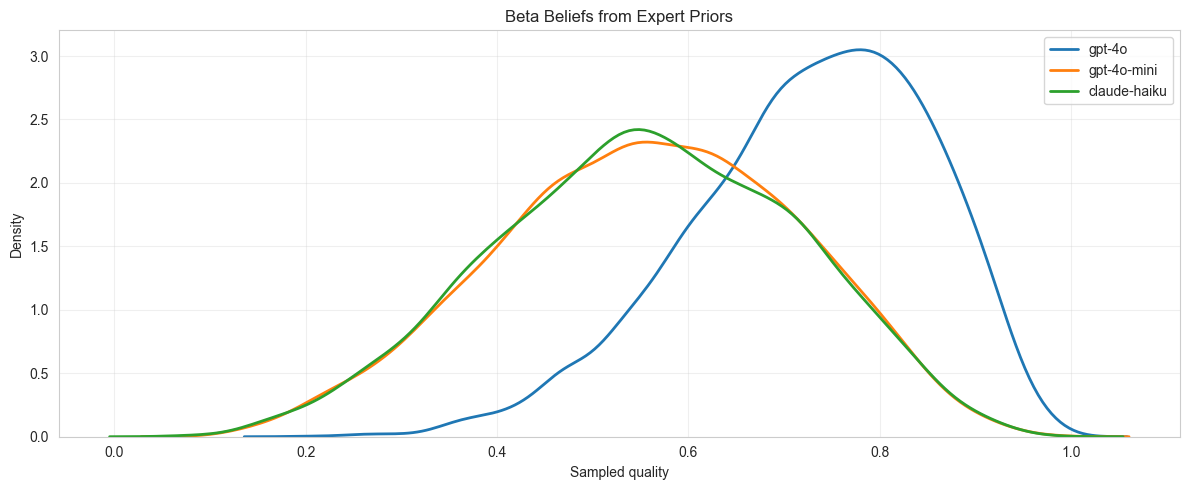

Intuition:
- `gpt-4o` starts with the highest prior mean, so it usually samples high.
- Cheaper models still occasionally sample higher, which creates exploration.
- Exploration is therefore uncertainty-aware, not arbitrary.


In [87]:
# Print the expert priors so you can see what alpha and beta mean concretely.
# EXPERT_PRIORS["gpt-4o"] = ModelConfig(alpha=8, beta=3)
# prior_mean = 8 / (8 + 3) = 0.727  -> the router starts believing gpt-4o is ~73% good
# EXPERT_PRIORS["gpt-4o-mini"] = ModelConfig(alpha=5, beta=4)
# prior_mean = 5 / (5 + 4) = 0.556  -> starts with ~56% confidence
expert_rows = []

EXPERT_PRIORS_1: dict[str, ModelConfig] = {
    "gpt-4o": ModelConfig(alpha=5, beta=3, cost_per_1k=0.005),
    "gpt-4o-mini": ModelConfig(alpha=5, beta=5, cost_per_1k=0.00015),
    "claude-haiku": ModelConfig(alpha=5, beta=4, cost_per_1k=0.00025),
}

for name, cfg in EXPERT_PRIORS_1.items():
    expert_rows.append(
        {
            "model": name,
            "alpha": cfg.alpha,         # effective "success count" before any real traffic
            "beta": cfg.beta,           # effective "failure count" before any real traffic
            "prior_mean": prior_mean(cfg),  # = alpha / (alpha + beta) = starting confidence
        }
    )

print("Expert priors shipped with the package:\n")
print_table(expert_rows)

# --- Thompson Sampling in action ---
# Each "round" is one routing decision.
# For each model: draw one random sample from Beta(alpha, beta).
# The model with the highest sample is chosen.
# Key: np.random.beta(alpha, beta) is a single random draw, not the distribution mean.
# That randomness is what drives exploration. If we used the mean every time,
# gpt-4o would always win and we would never learn about cheaper alternatives.
sample_rounds = []
for round_idx in range(1, 9):
    # Draw one value per model from its Beta belief.
    draws = {name: np.random.beta(cfg.alpha, cfg.beta) for name, cfg in EXPERT_PRIORS.items()}
    winner = max(draws, key=draws.get)   # model with the highest draw wins this request
    sample_rounds.append(
        {
            "round": round_idx,
            "gpt-4o_draw": draws["gpt-4o"],
            "gpt-4o-mini_draw": draws["gpt-4o-mini"],
            "claude-haiku_draw": draws["claude-haiku"],
            "winner": winner,    # notice: gpt-4o usually wins but not always
        }
    )

print("\nA few Thompson-sampling rounds from the prior beliefs:\n")
print_table(sample_rounds)

# --- KDE plot: visualise the Beta distributions ---
# Sampling 5000 values and plotting their density shows the shape of each belief.
# gpt-4o: peak shifted right (higher quality belief)
# cheaper models: wider curves (more uncertainty) that overlap gpt-4o's territory
# The overlap region is exactly where exploration happens — sometimes a cheaper model
# samples higher than gpt-4o and wins the routing decision.
sample_size = 5000
fig, ax = plt.subplots(figsize=(12, 5))
for name, cfg in EXPERT_PRIORS.items():
    samples = np.random.beta(cfg.alpha, cfg.beta, size=sample_size)
    sns.kdeplot(samples, label=name, linewidth=2, ax=ax)

ax.set_title("Beta Beliefs from Expert Priors")
ax.set_xlabel("Sampled quality")
ax.set_ylabel("Density")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print("Intuition:")
print("- `gpt-4o` starts with the highest prior mean, so it usually samples high.")
print("- Cheaper models still occasionally sample higher, which creates exploration.")
print("- Exploration is therefore uncertainty-aware, not arbitrary.")

## Part 4: One Request End to End Through the Real Package

This is the most important section for intuition.

We are going to follow exactly one request through the real router implementation:

1. inspect the starting beliefs
2. call `select()` to choose a model
3. simulate the primary call
4. compute the reward and update the selected model
5. optionally evaluate one shadow model in the background
6. inspect the beliefs again

This shows the entire loop in miniature.

To make the shadow path visible, the next cell sets `shadow_rate=1.0`, so one shadow model is always chosen. We keep `confidence_floor=0.0` so fallback does not get in the way of the first explanation.

---
### 💬 Say this on stage — Part 4

**Opening the request walkthrough:**
> "Let me slow down and trace exactly what happens to one request. This is the core loop. Everything else in the system is just adding production safety on top of this loop."

**On the 'state before' table:**
> "Before the request arrives, each model has an alpha and a beta. Alpha is evidence it tends to do well. Beta is evidence it tends to fall short. Confidence is just alpha divided by alpha plus beta. Notice gpt-4o starts with the highest confidence because it has the strongest expert prior."

**On select():**
> "When a request arrives, the router draws one random sample from each model's Beta distribution. The distributions are wide because we only have a handful of prior observations. The model with the highest sample wins. That is Thompson Sampling. It is a single random draw, not a formula, not a rule."

**On the telemetry and reward:**
> "The chosen model returns three signals. Did the output pass validation? How fast was it? Did the agent need to retry? Those three numbers go into the composite reward function. Out comes one number between 0 and 1."

**On the update:**
> "Now look at the 'state after' table. The chosen model's alpha increased by the reward. Its beta increased by one minus the reward. The belief shifted slightly. After thousands of queries, those small shifts add up to a very different routing distribution."

**On shadow:**
> "A second model was also evaluated in the background. It learned from this request too, but its answer was never served to the user. That is how we gather evidence safely."

**One-sentence version for any Q&A card:**
> "Every request runs the same five-step loop: sample, select, observe telemetry, compute reward, update belief."

In [88]:
random.seed(7)
np.random.seed(7)

# --- Build a fresh router for a single-request walkthrough ---
# confidence_floor=0.0: we want to see pure Thompson Sampling here, no fallback.
# shadow_rate=1.0: forces every request to also evaluate a shadow model, so we can
#   see that path clearly. In production you would use something like 0.05 (5%).
router = Router(
    models=clone_priors(EXPERT_PRIORS),
    gamma=0.95,
    decay_interval=50,
    confidence_floor=0.0,   # no fallback for this walkthrough
    shadow_rate=1.0,         # always choose a shadow model so we see both paths
    fallback_model="gpt-4o",
)
simulator = ModelSimulator(profiles=copy.deepcopy(DEFAULT_PROFILES))

# BEFORE the request: inspect alpha, beta, and confidence for each model.
# Compare these to the AFTER snapshot to see exactly how one request changes beliefs.
before_state = router.get_distributions()
print("State before the request:\n")
print_table(snapshot_rows(before_state))

# === STEP 1: SELECT ===
# router.select() does three things internally:
# (a) advances any circuit breakers that were waiting to reset
# (b) draws one np.random.beta(alpha, beta) sample per model
# (c) picks the model with the highest sample
# If that model's confidence < confidence_floor, it falls back to fallback_model.
# It also optionally chooses a shadow model.
selection = router.select()
print("\nSelection result:")
print(f"- served_model:      {selection.model}")
print(f"- selection_reason:  {selection.selection_reason}")   # "thompson" / "confidence_floor" / "circuit_open"
print(f"- fallback_used:     {selection.fallback_used}")       # True only if floor triggered
print(f"- shadow_model:      {selection.shadow_model}")        # second model evaluated silently

# === STEP 2: SIMULATE THE PRIMARY CALL ===
# In production this is where you call the real LLM API.
# The notebook normalizes telemetry so it works whether the simulator returns
# the old bool keys (is_valid, retried) or the new numeric keys
# (validity_score, retry_count).
primary = simulator.call(selection.model, tokens=500)
primary_validity_score = telemetry_validity_score(primary)
primary_retry_count = telemetry_retry_count(primary)

# === STEP 3: UPDATE THE PRIMARY MODEL'S BELIEF ===
# router.update() does:
#   reward = CompositeReward.compute(latency_ms, validity_score, retry_count)
#   alpha  += reward.total
#   beta   += (1 - reward.total)
#   query_count += 1
#   if query_count % decay_interval == 0: decay()
# Returns the RewardResult so we can log or inspect it.
primary_reward = router.update(
    selection.model,
    latency_ms=primary["latency_ms"],
    validity_score=primary_validity_score,
    retry_count=primary_retry_count,
)

# === STEP 4 (optional): EVALUATE THE SHADOW MODEL ===
# update_shadow() is identical to update() except it does NOT increment query_count.
# That means: the shadow model's belief is updated, but decay timing is not affected.
# The user never sees the shadow model's answer.
shadow = None
shadow_reward = None
if selection.shadow_model:
    shadow = simulator.call(selection.shadow_model, tokens=500)
    shadow_validity_score = telemetry_validity_score(shadow)
    shadow_retry_count = telemetry_retry_count(shadow)
    shadow_reward = router.update_shadow(
        selection.shadow_model,
        latency_ms=shadow["latency_ms"],
        validity_score=shadow_validity_score,
        retry_count=shadow_retry_count,
    )

# AFTER the request: compare to BEFORE to see how alpha/beta shifted.
after_state = router.get_distributions()

print("\nPrimary telemetry and reward breakdown:\n")
primary_rows = [
    {
        "model": selection.model,
        "latency_ms": primary["latency_ms"],
        "validity_score": primary_validity_score,
        "retry_count": primary_retry_count,
        "reward_validity": primary_reward.validity,    # 0.50 * validity_score
        "reward_latency": primary_reward.latency,      # sigmoid of latency
        "reward_retry": primary_reward.retry,          # graduated retry penalty
        "reward_total": primary_reward.total,          # sum of all three
    }
]
print_table(primary_rows)

if shadow is not None:
    print("\nShadow telemetry and reward breakdown:\n")
    shadow_rows = [
        {
            "model": selection.shadow_model,
            "latency_ms": shadow["latency_ms"],
            "validity_score": shadow_validity_score,
            "retry_count": shadow_retry_count,
            "reward_validity": shadow_reward.validity,
            "reward_latency": shadow_reward.latency,
            "reward_retry": shadow_reward.retry,
            "reward_total": shadow_reward.total,
        }
    ]
    print_table(shadow_rows)

# Compare before vs after to see the belief update.
# The primary model's alpha should have increased by ~reward_total.
# Its beta should have increased by ~(1 - reward_total).
print("\nState after the request:\n")
print_table(snapshot_rows(after_state))

print("\nWhat just happened:")
print("1. The router sampled each model's Beta belief and chose one primary model.")
print("2. The chosen model returned latency, validity, and retry telemetry.")
print("3. The composite reward converted that telemetry into one score in [0, 1].")
print("4. alpha increased by reward; beta increased by (1 - reward).")
print("5. A shadow model also learned in the background without serving the user.")

State before the request:

model        | alpha | beta | confidence | selections | shadow_selections | circuit_state | recent_failures
-------------+-------+------+------------+------------+-------------------+---------------+----------------
gpt-4o       | 8     | 3    | 0.727      | 0          | 0                 | closed        | 0              
gpt-4o-mini  | 5     | 4    | 0.556      | 0          | 0                 | closed        | 0              
claude-haiku | 5     | 4    | 0.556      | 0          | 0                 | closed        | 0              

Selection result:
- served_model:      gpt-4o
- selection_reason:  thompson
- fallback_used:     False
- shadow_model:      gpt-4o-mini

Primary telemetry and reward breakdown:

model  | latency_ms | validity_score | retry_count | reward_validity | reward_latency | reward_retry | reward_total
-------+------------+----------------+-------------+-----------------+----------------+--------------+-------------
gpt-4o | 1801.698   | 

## Part 5: Cold Start — Expert Priors vs Uniform Priors

This is the first major production addition beyond textbook Thompson Sampling.

Without priors:
- every model starts at `Beta(1, 1)`
- the router begins in near-total ignorance
- early traffic is spent rediscovering obvious facts

With expert priors:
- the stronger model starts with a higher prior mean
- cheaper models still get explored
- but the first few dozen queries are less wasteful and safer

Important nuance:
- priors are not magic
- they do not guarantee the router is correct
- they only help when they are aligned with the reward being optimized

Because the notebook's default reward gives a lot of credit to fast cheap models, this section uses a **quality-first reward** on purpose.
That makes `gpt-4o` the right early choice, so the expert priors can demonstrate their intended advantage clearly.

For a clean comparison, the next cell disables fallback, shadow traffic, and decay. That isolates the effect of priors alone.

---
### 💬 Say this on stage — Part 5

**Opening the priors section:**
> "Even before the first query arrives, we give the router a head start. Instead of starting completely blind with Beta(1,1) for every model, we initialize with beliefs that reflect what public benchmarks already tell us. gpt-4o starts with a higher prior mean. The cheaper models start lower, but still get explored."

**Very important setup note:**
> "In this section I am using a more quality-first reward on purpose. Otherwise the default reward in the simulator gives so much credit to speed that the cheap models can outperform gpt-4o on composite reward, which would make the priors look misleadingly bad. Here I want to isolate the real cold-start idea: if the stronger model is actually the right early choice, aligned expert priors help you get there faster."

**Pointing at the early traffic bar chart:**
> "Look at the first 20 queries. With expert priors, the router immediately gives more traffic to gpt-4o because it starts with a better belief about it. With uniform priors, the early traffic is much flatter because the router genuinely does not know which model is better yet."

**On what priors are not:**
> "This is not about hardcoding a rule that says 'always use gpt-4o first.' The priors just set the starting point. The router will override them quickly if the evidence says otherwise. Think of it as giving a new employee a reasonable briefing before their first shift, rather than letting them discover everything by trial and error."

**On the convergence claim:**
> "Aligned expert priors reduce cold-start regret. They let the router spend fewer early requests rediscovering obvious facts and more quickly route toward the model that the current objective actually prefers."

**One-sentence version for any Q&A card:**
> "Expert priors help only when they are aligned with the reward being optimized — when they are, they make the first few dozen queries much less wasteful."

Priors used in this comparison:

setup   | model        | alpha | beta | prior_mean
--------+--------------+-------+------+-----------
Expert  | gpt-4o       | 8     | 3    | 0.727     
Expert  | gpt-4o-mini  | 5     | 4    | 0.556     
Expert  | claude-haiku | 5     | 4    | 0.556     
Uniform | gpt-4o       | 1     | 1    | 0.500     
Uniform | gpt-4o-mini  | 1     | 1    | 0.500     
Uniform | claude-haiku | 1     | 1    | 0.500     

Part 5 uses a quality-first reward:

validity_weight | latency_weight | retry_weight
----------------+----------------+-------------
0.900           | 0.050          | 0.050       

Cold-start comparison under quality-first reward:

setup          | avg_reward_first_20 | avg_reward_first_50 | most_common_choice_first_20
---------------+---------------------+---------------------+----------------------------
Expert priors  | 0.887               | 0.908               | gpt-4o                     
Uniform priors | 0.836               | 0.874              

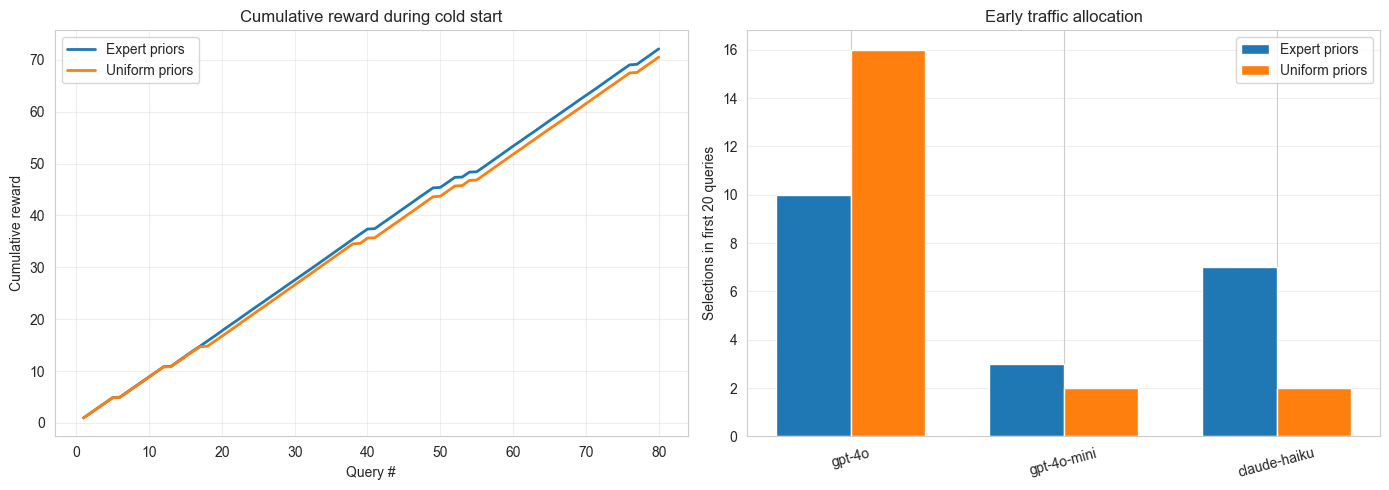

Intuition:
- Expert priors start the router closer to reality.
- Uniform priors force the router to spend more early traffic rediscovering the obvious.
- This is why priors reduce cold-start regret.


In [89]:
# Print both prior sets side by side so the starting difference is visible.
# EXPERT:  gpt-4o starts at 0.727, cheaper models at 0.556 — informed by benchmarks.
# UNIFORM: all three models start at 0.500 — maximum ignorance.
prior_rows = []
for setup_name, priors in [("Expert", EXPERT_PRIORS), ("Uniform", UNIFORM_PRIORS)]:
    for name, cfg in priors.items():
        prior_rows.append(
            {
                "setup": setup_name,
                "model": name,
                "alpha": cfg.alpha,
                "beta": cfg.beta,
                "prior_mean": prior_mean(cfg),   # alpha / (alpha + beta)
            }
        )

print("Priors used in this comparison:\n")
print_table(prior_rows)

# For this section only, use a quality-first reward so the stronger model
# (gpt-4o) is actually the best early choice under the objective being optimized.
# This makes the cold-start benefit of aligned expert priors much clearer.
part5_reward = CompositeReward(
    validity_weight=0.90,
    latency_weight=0.05,
    retry_weight=0.05,
)

print("\nPart 5 uses a quality-first reward:\n")
print_table([
    {
        "validity_weight": part5_reward.validity_weight,
        "latency_weight": part5_reward.latency_weight,
        "retry_weight": part5_reward.retry_weight,
    }
])

# --- Run two identical simulations, only the priors differ ---
# gamma=1.0 disables decay so we isolate the prior effect.
# confidence_floor=0.0 and shadow_rate=0.0 remove the other production layers.
# reward_fn=part5_reward ensures the stronger model is the correct early target.
_, expert_records = run_router_simulation(
    priors=EXPERT_PRIORS,
    num_queries=80,
    seed=11,
    gamma=1.0,           # no decay — isolating priors
    confidence_floor=0.0,
    shadow_rate=0.0,
    reward_fn=part5_reward,
)
_, uniform_records = run_router_simulation(
    priors=UNIFORM_PRIORS,
    num_queries=80,
    seed=11,           # same seed so any difference is due to priors, not randomness
    gamma=1.0,
    confidence_floor=0.0,
    shadow_rate=0.0,
    reward_fn=part5_reward,
)

# Summarize the first 20 and first 50 queries.
# avg_reward_first_20 shows how well the router performs before it has much data.
# most_common_choice shows whether it immediately exploits the stronger model or wastes time exploring.
comparison_rows = []
for label, records in [("Expert priors", expert_records), ("Uniform priors", uniform_records)]:
    first_20 = records[:20]
    first_50 = records[:50]
    comparison_rows.append(
        {
            "setup": label,
            "avg_reward_first_20": average([row["reward_total"] for row in first_20]),
            "avg_reward_first_50": average([row["reward_total"] for row in first_50]),
            "most_common_choice_first_20": Counter(row["served_model"] for row in first_20).most_common(1)[0][0],
        }
    )

print("\nCold-start comparison under quality-first reward:\n")
print_table(comparison_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, records in [("Expert priors", expert_records), ("Uniform priors", uniform_records)]:
    cumulative_reward = np.cumsum([row["reward_total"] for row in records])
    axes[0].plot([row["query_id"] for row in records], cumulative_reward, linewidth=2, label=label)

axes[0].set_title("Cumulative reward during cold start")
axes[0].set_xlabel("Query #")
axes[0].set_ylabel("Cumulative reward")
axes[0].legend()
axes[0].grid(alpha=0.3)

model_order = list(EXPERT_PRIORS.keys())
expert_counts = Counter(row["served_model"] for row in expert_records[:20])
uniform_counts = Counter(row["served_model"] for row in uniform_records[:20])
x = np.arange(len(model_order))
width = 0.35
axes[1].bar(x - width / 2, [expert_counts.get(model, 0) for model in model_order], width, label="Expert priors")
axes[1].bar(x + width / 2, [uniform_counts.get(model, 0) for model in model_order], width, label="Uniform priors")
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_order, rotation=15)
axes[1].set_ylabel("Selections in first 20 queries")
axes[1].set_title("Early traffic allocation")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Intuition:")
print("- Expert priors start the router closer to reality.")
print("- Uniform priors force the router to spend more early traffic rediscovering the obvious.")
print("- This is why priors reduce cold-start regret.")

## Part 6: Decay and Model Rot

This is the second major production addition.

Provider quality drifts over time.
A model that was best last week may become slower or worse today.

Without decay:
- `alpha` and `beta` keep growing forever
- the router becomes very confident in old history
- new bad evidence has little effect

With decay:
- old evidence fades gradually
- recent evidence has more influence
- the router can recover when a provider degrades

There is one more important point:
- **decay alone is not enough if the router never gathers fresh evidence about alternatives**
- in this section we keep a small amount of **shadow evaluation** turned on so the non-served models continue learning in the background
- that makes the difference between `gamma = 1.0` and `gamma < 1.0` visible in a realistic way

This section also uses:
- a **quality-first reward**, so `gpt-4o` really is the correct early choice
- **stronger expert priors**, so the router builds up a meaningful stale belief before drift happens

The next cell compares two runs of the real router:
- `gamma = 1.0` (no decay)
- `gamma = 0.90` (clearer, more aggressive decay for the demo)

At query 150, `gpt-4o` is degraded sharply. Watch how much faster the router with decay moves traffic away afterward.

One subtle point: if the summary says `gpt-4o` share is `0%` in the last 80 queries for the decay run, that does **not** mean the model is permanently impossible to select. It means that in this particular run, over that final 80-query window, the combination of:

- repeated poor post-degradation rewards for `gpt-4o`
- periodic shrinking of old evidence
- ongoing shadow learning about the alternatives

was strong enough that `gpt-4o` never produced the highest Thompson sample in that window.

---
### 💬 Say this on stage — Part 6

**Opening the decay section:**
> "Now here is the production problem that almost every benchmark paper ignores: model quality is not stable. Providers update their models. Latency changes. The model that was best last Monday may be slower or less reliable by Friday. Your router needs to adapt."

**Very important setup note:**
> "To make the effect visible, this demo does three things on purpose. First, it uses a quality-first reward, so gpt-4o is the right early choice. Second, it uses stronger priors, so the router builds up real confidence in gpt-4o before anything goes wrong. Third, it keeps a small amount of shadow evaluation on, because without some fresh evidence about alternatives, decay has nothing useful to act on."

**On the traffic-share plot:**
> "Before the red dashed line, both runs behave similarly — almost all traffic goes to gpt-4o. That is exactly what we want. It means the router really believed gpt-4o was the best model. After the degradation, the difference begins. The no-decay run keeps sending too much traffic to gpt-4o because its old belief is still sticky. The decay run lets that old belief weaken, so the alternatives can overtake it sooner."

**If someone asks, 'why does gpt-4o hit 0% share in the last 80 queries?':**
> "Because by that point, in this specific run, three things have all happened together: gpt-4o has accumulated a lot of poor rewards after the degradation, decay has reduced the weight of its old good history, and shadow traffic has kept teaching the router about the alternative models. So in that final window, gpt-4o never produced the highest Thompson sample. Zero percent here means it lost every request in that window, not that it is mathematically impossible for it to win again forever."

**On the post-degradation reward plot:**
> "I am plotting cumulative reward starting from the moment of degradation, not from query 1, because that makes the comparison fair and visible. Up to the degradation point the two runs are supposed to look similar. The interesting question is what happens after the drift. That is what this plot isolates."

**On why shadow matters here:**
> "Decay does not magically invent new information. It just makes old information matter less. You still need some ongoing learning signal about the other models. In this router, shadow traffic provides that signal safely in the background."

**Anticipating the 'how do you choose gamma?' question:**
> "Set the half-life to roughly half the expected time between provider changes. If your provider updates every week and you serve 10,000 queries a week, you want old evidence to count half as much after about 5,000 queries. You can derive gamma from that target."

**One-sentence version for any Q&A card:**
> "Decay makes the router adaptive: old evidence fades, but you still need some ongoing evidence about alternatives for that adaptation to matter."

Model-rot comparison summary:

run        | gpt4o_share_first_150 | gpt4o_share_after_degrade | avg_reward_after_degrade | gpt4o_share_last_80
-----------+-----------------------+---------------------------+--------------------------+--------------------
No decay   | 0.987                 | 0.120                     | 0.837                    | 0.100              
With decay | 0.987                 | 0.028                     | 0.906                    | 0.000000           

Final belief state by model:

run        | model        | alpha   | beta   | total_evidence | confidence
-----------+--------------+---------+--------+----------------+-----------
No decay   | gpt-4o       | 172.306 | 42.694 | 215.000        | 0.801     
No decay   | gpt-4o-mini  | 65.548  | 15.452 | 81.000         | 0.809     
No decay   | claude-haiku | 177.740 | 22.260 | 200.000        | 0.889     
With decay | gpt-4o       | 79.204  | 17.277 | 96.481         | 0.821     
With decay | gpt-4o-mini  | 51.283  | 9.

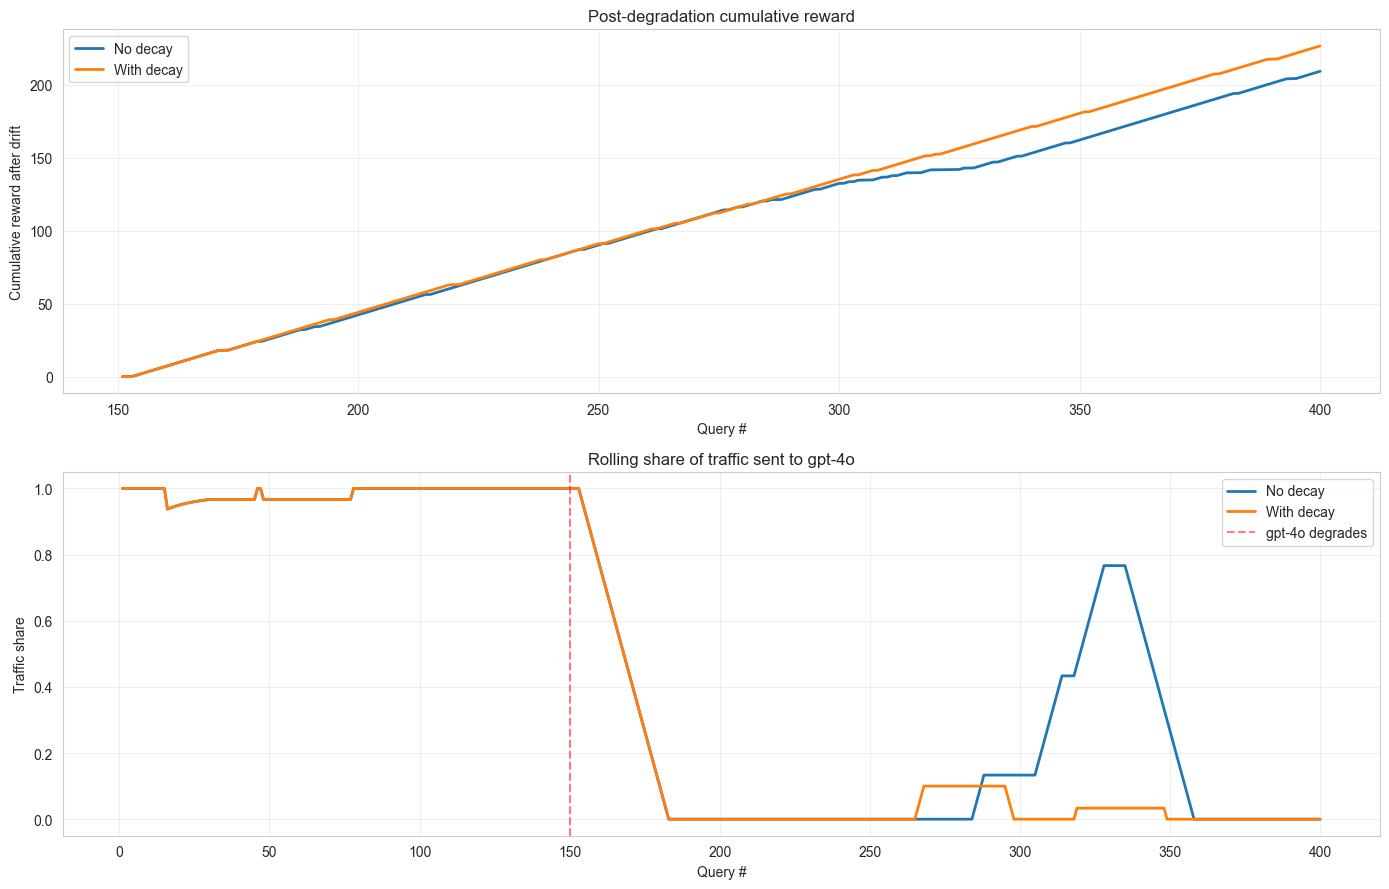

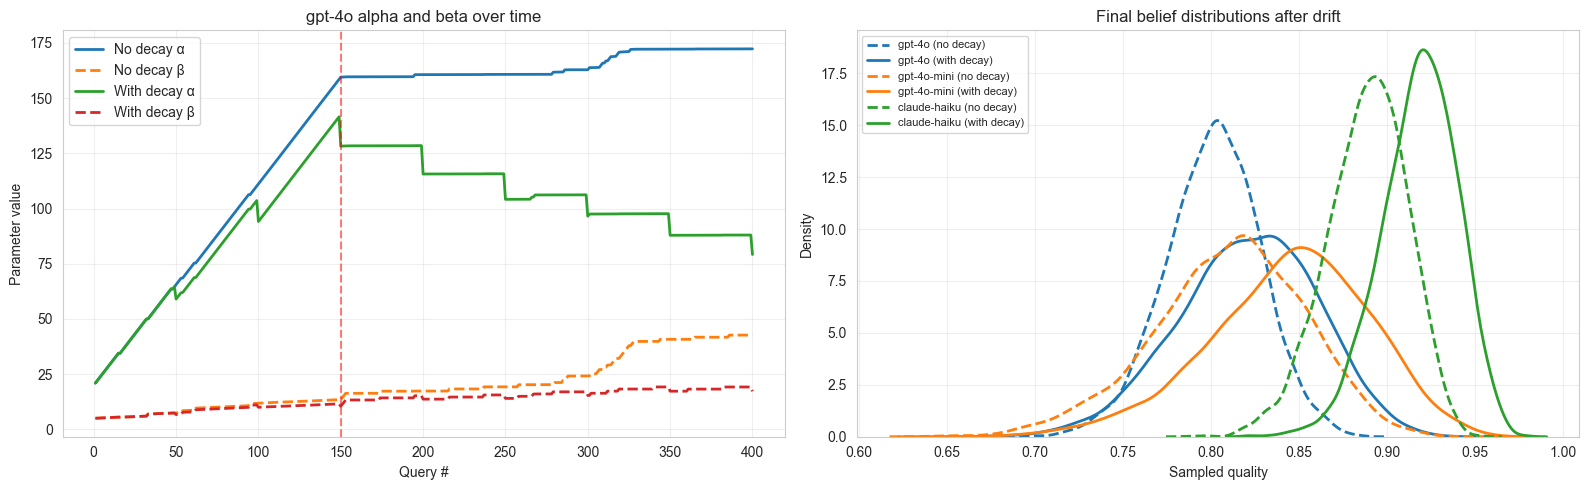

Why can gpt-4o share be 0% in the last 80 queries?
- In the decay run, repeated poor rewards after the degradation move gpt-4o's belief left.
- Decay shrinks old evidence, so its earlier good history matters less.
- Shadow traffic keeps updating the cheaper models in the background, so they remain competitive.
- In this specific run, over the last 80 queries, gpt-4o never produced the highest Thompson sample, so its share in that window is 0%.
- That does not mean it is impossible for gpt-4o to win again forever; it only means it did not win in that final window.

Intuition:
- Before degradation, both runs strongly prefer gpt-4o.
- After degradation, no-decay keeps too much stale confidence in gpt-4o.
- With decay, old evidence weakens, so traffic shifts away faster and reward recovers sooner.


In [90]:
# This section is deliberately configured to make stale confidence visible.
# 1. quality-first reward -> gpt-4o is genuinely the best early choice
# 2. stronger priors      -> router becomes highly confident in gpt-4o before drift
# 3. small shadow rate    -> alternatives keep learning in the background
# 4. stronger degradation -> the drift is large enough to matter clearly

part6_reward = CompositeReward(
    validity_weight=0.90,
    latency_weight=0.05,
    retry_weight=0.05,
)

part6_priors = {
    "gpt-4o": ModelConfig(alpha=20, beta=5, cost_per_1k=0.005),
    "gpt-4o-mini": ModelConfig(alpha=5, beta=5, cost_per_1k=0.00015),
    "claude-haiku": ModelConfig(alpha=5, beta=5, cost_per_1k=0.00025),
}

# At query 150, gpt-4o is degraded by a factor of 3.0.
# factor=3.0 means: latency * 3 and validity / 3 inside the simulator.
# The router does not "know" this happened. It only sees worse rewards after query 150.
degradation = {"model": "gpt-4o", "factor": 3.0, "at_query": 150}

# Run 1: no decay (gamma=1.0 means alpha and beta keep growing forever).
# Old evidence accumulates and never weakens. After 150 queries of strong gpt-4o performance,
# the posterior is very confident. New bad evidence arrives, but the old belief is sticky.
_, no_decay_records = run_router_simulation(
    priors=part6_priors,
    num_queries=400,
    seed=19,
    gamma=1.0,           # no decay — old evidence never fades
    confidence_floor=0.0,
    shadow_rate=0.10,    # keep some safe background learning about alternatives
    degradation=degradation,
    reward_fn=part6_reward,
)

# Run 2: decay enabled (gamma=0.90, every 50 queries evidence shrinks by 10%).
# Old evidence fades more aggressively for the sake of a clearer demo.
# When degradation hits at query 150, new bad rewards can shift the belief sooner.
_, decay_records = run_router_simulation(
    priors=part6_priors,
    num_queries=400,
    seed=19,             # same seed for a fair comparison
    gamma=0.90,          # stronger decay so the contrast is visually clearer
    confidence_floor=0.0,
    shadow_rate=0.10,
    degradation=degradation,
    reward_fn=part6_reward,
)

summary_rows = [
    {
        "run": "No decay",
        "gpt4o_share_first_150": average([1.0 if row["served_model"] == "gpt-4o" else 0.0 for row in no_decay_records[:150]]),
        "gpt4o_share_after_degrade": average([1.0 if row["served_model"] == "gpt-4o" else 0.0 for row in no_decay_records[150:]]),
        "avg_reward_after_degrade": average([row["reward_total"] for row in no_decay_records[150:]]),
        "gpt4o_share_last_80": average([1.0 if row["served_model"] == "gpt-4o" else 0.0 for row in no_decay_records[-80:]]),
    },
    {
        "run": "With decay",
        "gpt4o_share_first_150": average([1.0 if row["served_model"] == "gpt-4o" else 0.0 for row in decay_records[:150]]),
        "gpt4o_share_after_degrade": average([1.0 if row["served_model"] == "gpt-4o" else 0.0 for row in decay_records[150:]]),
        "avg_reward_after_degrade": average([row["reward_total"] for row in decay_records[150:]]),
        "gpt4o_share_last_80": average([1.0 if row["served_model"] == "gpt-4o" else 0.0 for row in decay_records[-80:]]),
    },
]
print("Model-rot comparison summary:\n")
print_table(summary_rows)

# Also show the final alpha/beta/confidence values for each model in each run.
# This makes the stale-confidence story explicit instead of relying only on traffic share.
final_state_rows = []
for label, records in [("No decay", no_decay_records), ("With decay", decay_records)]:
    last = records[-1]
    for model_name in ["gpt-4o", "gpt-4o-mini", "claude-haiku"]:
        safe_name = model_name.replace("-", "_")
        alpha = last[f"{safe_name}_alpha"]
        beta = last[f"{safe_name}_beta"]
        final_state_rows.append(
            {
                "run": label,
                "model": model_name,
                "alpha": alpha,
                "beta": beta,
                "total_evidence": alpha + beta,
                "confidence": last[f"{safe_name}_confidence"],
            }
        )

print("\nFinal belief state by model:\n")
print_table(final_state_rows)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Plot 1: focus only on reward AFTER the degradation point.
# Both runs are expected to look similar before query 150.
# Re-basing here makes the post-drift difference easier to see.
post_q_no = [row["query_id"] for row in no_decay_records[150:]]
post_q_de = [row["query_id"] for row in decay_records[150:]]
post_cum_no = np.cumsum([row["reward_total"] for row in no_decay_records[150:]])
post_cum_de = np.cumsum([row["reward_total"] for row in decay_records[150:]])
axes[0].plot(post_q_no, post_cum_no, linewidth=2, label="No decay")
axes[0].plot(post_q_de, post_cum_de, linewidth=2, label="With decay")
axes[0].set_title("Post-degradation cumulative reward")
axes[0].set_xlabel("Query #")
axes[0].set_ylabel("Cumulative reward after drift")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: rolling share of traffic sent to gpt-4o.
# Before query 150 both lines should be very high and almost identical.
# After query 150, the decay run should move away from gpt-4o more decisively.
axes[1].plot(
    [row["query_id"] for row in no_decay_records],
    rolling_model_share(no_decay_records, "gpt-4o", window=30),
    linewidth=2,
    label="No decay",
)
axes[1].plot(
    [row["query_id"] for row in decay_records],
    rolling_model_share(decay_records, "gpt-4o", window=30),
    linewidth=2,
    label="With decay",
)
axes[1].axvline(degradation["at_query"], color="red", linestyle="--", alpha=0.5, label="gpt-4o degrades")
axes[1].set_title("Rolling share of traffic sent to gpt-4o")
axes[1].set_xlabel("Query #")
axes[1].set_ylabel("Traffic share")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Second figure: alpha/beta trajectories and final belief distributions.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 3: gpt-4o alpha/beta over time.
# No-decay should keep pushing both upward forever.
# Decay should periodically pull them down, reducing stale confidence.
q_no = [row["query_id"] for row in no_decay_records]
q_de = [row["query_id"] for row in decay_records]
axes[0].plot(q_no, [row["gpt_4o_alpha"] for row in no_decay_records], linewidth=2, label="No decay α")
axes[0].plot(q_no, [row["gpt_4o_beta"] for row in no_decay_records], linewidth=2, linestyle="--", label="No decay β")
axes[0].plot(q_de, [row["gpt_4o_alpha"] for row in decay_records], linewidth=2, label="With decay α")
axes[0].plot(q_de, [row["gpt_4o_beta"] for row in decay_records], linewidth=2, linestyle="--", label="With decay β")
axes[0].axvline(degradation["at_query"], color="red", linestyle="--", alpha=0.5)
axes[0].set_title("gpt-4o alpha and beta over time")
axes[0].set_xlabel("Query #")
axes[0].set_ylabel("Parameter value")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 4: final Beta belief distributions for all models in each run.
# The 0% share in the last 80 queries happens because, in the decay run,
# gpt-4o's final belief has shifted left enough that it no longer wins samples in that window.
rng = np.random.default_rng(12345)
for model_name, color in [("gpt-4o", "tab:blue"), ("gpt-4o-mini", "tab:orange"), ("claude-haiku", "tab:green")]:
    safe_name = model_name.replace("-", "_")
    nd_samples = rng.beta(no_decay_records[-1][f"{safe_name}_alpha"], no_decay_records[-1][f"{safe_name}_beta"], size=4000)
    d_samples = rng.beta(decay_records[-1][f"{safe_name}_alpha"], decay_records[-1][f"{safe_name}_beta"], size=4000)
    sns.kdeplot(nd_samples, ax=axes[1], color=color, linewidth=2, linestyle="--", label=f"{model_name} (no decay)")
    sns.kdeplot(d_samples, ax=axes[1], color=color, linewidth=2, label=f"{model_name} (with decay)")
axes[1].set_title("Final belief distributions after drift")
axes[1].set_xlabel("Sampled quality")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Why can gpt-4o share be 0% in the last 80 queries?")
print("- In the decay run, repeated poor rewards after the degradation move gpt-4o's belief left.")
print("- Decay shrinks old evidence, so its earlier good history matters less.")
print("- Shadow traffic keeps updating the cheaper models in the background, so they remain competitive.")
print("- In this specific run, over the last 80 queries, gpt-4o never produced the highest Thompson sample, so its share in that window is 0%.")
print("- That does not mean it is impossible for gpt-4o to win again forever; it only means it did not win in that final window.")

print("\nIntuition:")
print("- Before degradation, both runs strongly prefer gpt-4o.")
print("- After degradation, no-decay keeps too much stale confidence in gpt-4o.")
print("- With decay, old evidence weakens, so traffic shifts away faster and reward recovers sooner.")

## Part 7: Safety — Fallback and Shadow Evaluation

The talk is much stronger when you make the safety story explicit.

### Confidence-floor fallback
If the selected model's current confidence is below a floor, the router serves a trusted fallback model instead.

This means the system is not saying:
> trust the cheap model and hope

It is saying:
> explore, but only serve a model if it is trusted enough

### Shadow evaluation
A second model can be evaluated silently on the same request.
That model learns from the query, but its answer is not served to the user.

This is how the router can gather evidence about alternatives safely.

The next cell exaggerates both mechanisms so they are visible in a short 60-query run.

---
### 💬 Say this on stage — Part 7

**Opening the safety section:**
> "At this point you might be thinking: this all sounds risky. You're routing user traffic to cheaper models based on a probability distribution. What stops it from sending requests to a model it is barely confident in?"

**On fallback:**
> "This is where the confidence floor comes in. If the selected model's current mean — alpha divided by alpha plus beta — is below a threshold, we do not serve it. We fall back to the trusted model. You can set that floor to anything: 60%, 70%, 80%. The router will not route real traffic to any model it does not trust yet."

> "Look at the selection reasons table. Early in the run you see 'confidence_floor' appearing. That is the safety mechanism working. The router wanted to send traffic to a cheaper model, saw it was not confident enough yet, and served gpt-4o instead. That is not a failure. That is the intended behavior."

**On shadow evaluation:**
> "And how do we get confident enough to eventually trust a cheaper model? Shadow evaluation. One in four requests in this example gets a second model evaluated in the background. That model never serves the user. Its answer is discarded. But its reward is used to update its belief. So we learn about it safely."

**The key message:**
> "The combination of these two mechanisms is why the story is not 'trust the cheap model and hope.' It is 'explore carefully, fall back when uncertain, and only shift traffic when you have real evidence.'"

**One-sentence version for any Q&A card:**
> "Fallback catches individual low-confidence decisions. Shadow evaluation gathers evidence without taking risk."

Safety summary:

metric         | value  
---------------+--------
fallback_rate  | 0.017  
shadow_rate    | 0.250  
avg_reward     | 0.914  
avg_latency_ms | 967.282

Selection reasons:

selection_reason | count
-----------------+------
confidence_floor | 1    
thompson         | 59   

First 12 queries so you can inspect fallback and shadow behavior:

query_id | served_model | selection_reason | fallback_used | shadow_model | reward_total | latency_ms
---------+--------------+------------------+---------------+--------------+--------------+-----------
1        | gpt-4o       | confidence_floor | True          | gpt-4o-mini  | 0.871        | 1829.899  
2        | gpt-4o       | thompson         | False         |              | 0.788        | 2524.912  
3        | gpt-4o       | thompson         | False         | claude-haiku | 0.820        | 2242.093  
4        | gpt-4o-mini  | thompson         | False         | gpt-4o       | 0.938        | 1198.049  
5        | gpt-4o       | thomps

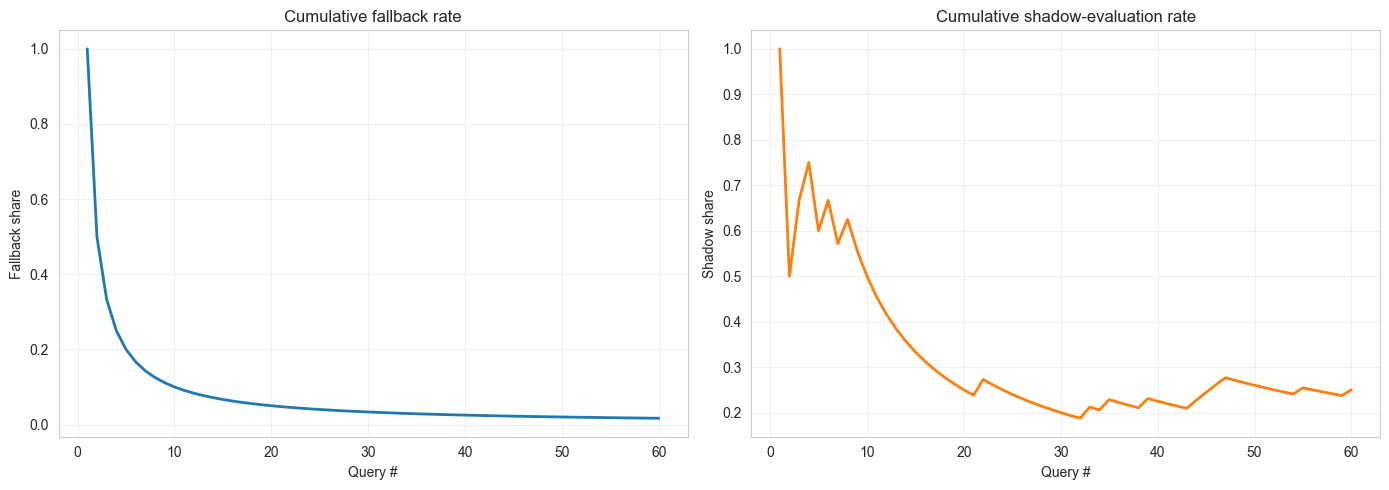

Intuition:
- Early on, fallback fires often because the router is still uncertain.
- Shadow evaluation lets alternatives learn without taking user-facing risk.
- As beliefs improve, fallback rate should come down.


In [91]:
# Use UNIFORM_PRIORS so all models start at Beta(1,1), meaning the router is nearly uncertain.
# This ensures fallback fires often early (because confidence is below the 0.65 floor).
# With EXPERT_PRIORS the router would start above the floor and fallback would be rarer.
_, safety_records = run_router_simulation(
    priors=UNIFORM_PRIORS,
    num_queries=60,
    seed=21,
    gamma=0.95,
    confidence_floor=0.65,   # models must have confidence >= 0.65 to serve users directly
                              # early on, Beta(1,1) gives mean=0.50 < 0.65, so fallback fires
    shadow_rate=0.25,         # 1 in 4 requests silently evaluates a second model
    fallback_model="gpt-4o",  # when confidence is too low, route to this trusted model
)

# The "fallback_rate" shows how often the selected model's confidence was below the floor.
# The "shadow_rate" shows how often a second model was evaluated in the background.
# Both rates should decrease over time as the router learns and becomes more confident.
safety_summary = [
    {"metric": "fallback_rate",    "value": average([1.0 if row["fallback_used"] else 0.0 for row in safety_records])},
    {"metric": "shadow_rate",      "value": average([1.0 if row["shadow_model"] is not None else 0.0 for row in safety_records])},
    {"metric": "avg_reward",       "value": average([row["reward_total"] for row in safety_records])},
    {"metric": "avg_latency_ms",   "value": average([row["latency_ms"] for row in safety_records])},
]
print("Safety summary:\n")
print_table(safety_summary)

# "selection_reason" shows WHY the router made each decision:
# "thompson"          = normal Thompson Sampling decision
# "confidence_floor"  = fallback triggered because selected model was not trusted enough
# "circuit_open"      = fallback triggered because a model's circuit was open
reason_rows = [{"selection_reason": reason, "count": count} for reason, count in Counter(row["selection_reason"] for row in safety_records).items()]
print("\nSelection reasons:\n")
print_table(reason_rows)

# Show the first 12 rows to trace fallback and shadow on a per-request basis.
# Look at: fallback_used=True when selection_reason="confidence_floor"
#          shadow_model is not None when a shadow evaluation happened
print("\nFirst 12 queries so you can inspect fallback and shadow behavior:\n")
print_table(
    safety_records,
    columns=["query_id", "served_model", "selection_reason", "fallback_used", "shadow_model", "reward_total", "latency_ms"],
    max_rows=12,
)

query_ids = [row["query_id"] for row in safety_records]
fallback_curve = cumulative_rate(safety_records, lambda row: row["fallback_used"])
shadow_curve = cumulative_rate(safety_records, lambda row: row["shadow_model"] is not None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(query_ids, fallback_curve, linewidth=2)
axes[0].set_title("Cumulative fallback rate")
axes[0].set_xlabel("Query #")
axes[0].set_ylabel("Fallback share")
axes[0].grid(alpha=0.3)

axes[1].plot(query_ids, shadow_curve, linewidth=2, color="tab:orange")
axes[1].set_title("Cumulative shadow-evaluation rate")
axes[1].set_xlabel("Query #")
axes[1].set_ylabel("Shadow share")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Intuition:")
print("- Early on, fallback fires often because the router is still uncertain.")
print("- Shadow evaluation lets alternatives learn without taking user-facing risk.")
print("- As beliefs improve, fallback rate should come down.")

## Part 8: Circuit Breakers

Circuit breakers answer a different safety question:

> What if one provider starts failing repeatedly and should stop receiving user traffic immediately?

The router tracks recent failures for each model and moves that model through states:

- `closed`: normal routing
- `open`: blocked from primary traffic
- `half-open`: allowed back only as a cautious probe
- `closed` again after successful probes

The next cell drives that state machine step by step so you can see exactly how it behaves.

---
### 💬 Say this on stage — Part 8

**Opening the table:**
> "This is the last safety layer. Circuit breakers answer a different question from fallback. Fallback is about individual request confidence. Circuit breakers are about detecting a provider that is structurally broken."

**Walking the state transitions:**
> "The table reads like a story. Start at the top: everything is closed, normal routing. Two failures in a row — that crosses our threshold of two failures in a three-request window. Circuit opens. The model is blocked from user traffic immediately."

> "Then four safe queries pass on another model. The reset window expires. The circuit goes half-open. This is the cautious re-entry. The degraded model is allowed back only as a shadow evaluation — it gets to try, but users never see its answer."

> "Two successful shadow probes later, the circuit closes. The model is back in normal rotation."

**Handling the 'what counts as a failure?' question:**
> "In the implementation, a failure is defined as either a failed validity check or a non-zero retry count. So it is triggered by the same telemetry signals that drive the composite reward. No extra instrumentation needed."

**One-sentence version for any Q&A card:**
> "Circuit breakers protect users when a model starts failing systemically, not just occasionally."

In [92]:
# Use small parameter values so the full open->half-open->closed cycle
# completes in just a few steps and is easy to read in the table.
#   circuit_window_size=3         -> track only the last 3 outcomes
#   circuit_failure_threshold=2   -> 2 failures in that window open the circuit
#   circuit_reset_queries=4       -> after 4 primary queries on other models -> move to half-open
#   half_open_max_requests=2      -> 2 successful probes needed to close again
# In production you would use larger values (e.g. window=10, threshold=5).
breaker_router = Router(
    models=clone_priors(EXPERT_PRIORS),
    gamma=1.0,
    decay_interval=10_000,   # disable decay so it does not obscure the circuit-breaker logic
    confidence_floor=0.0,    # disable fallback so only circuit-breaker decisions appear
    shadow_rate=0.0,         # we will set shadow to 0 and drive probes manually for clarity
    circuit_window_size=3,
    circuit_failure_threshold=2,
    circuit_reset_queries=4,
    half_open_max_requests=2,
)

target_model = "gpt-4o-mini"   # the model we will break, then recover
breaker_events = []


def record_breaker_state(step_label, selection=None):
    # Capture a snapshot of target_model's circuit state after each action.
    # total_queries tells us where in the circuit_reset_queries window we are.
    state = breaker_router.get_distributions()[target_model]
    stats = breaker_router.get_stats()
    breaker_events.append(
        {
            "step": step_label,
            "total_queries": stats["total_queries"],
            "served_model": None if selection is None else selection.model,
            "shadow_model": None if selection is None else selection.shadow_model,
            "selection_reason": None if selection is None else selection.selection_reason,
            "target_circuit_state": state.circuit_state,   # closed / open / half-open
            "recent_failures": state.recent_failures,       # count of failures in window
            "target_confidence": state.confidence,
        }
    )


record_breaker_state("Initial state")   # circuit_state="closed" for all models

# --- STEP 1: Inject two failures into gpt-4o-mini ---
# A "failure" is defined as: (validity_score < threshold) OR (retry_count > 0).
# Two failures within the last 3 outcomes crosses our threshold of 2.
breaker_router.update(target_model, latency_ms=3200, validity_score=0.0, retry_count=1)
record_breaker_state("Failure #1")   # recent_failures=1, circuit still closed

breaker_router.update(target_model, latency_ms=3400, validity_score=0.0, retry_count=1)
record_breaker_state("Failure #2 -> circuit opens")
# After this update: recent_failures=2 >= threshold=2 -> circuit moves to "open"
# gpt-4o-mini is now blocked from primary traffic.

# --- STEP 2: Advance time with safe queries on gpt-4o ---
# The circuit stays "open" while query_count < circuit_reopen_query.
# circuit_reopen_query is set to (current_query_count + circuit_reset_queries) when the circuit opens.
# We need 4 primary queries on any model to reach that count.
for _ in range(4):
    breaker_router.update("gpt-4o", latency_ms=900, validity_score=1.0, retry_count=0)
record_breaker_state("Reset window elapsed")
# After this: the router is ready to move gpt-4o-mini to "half-open" on the next select().

# --- STEP 3: Half-open probes ---
# The first select() after the reset window triggers open->half-open transition.
# In half-open state, gpt-4o-mini is NOT served as primary.
# Instead, it appears as a shadow model — a cautious probe without user exposure.
probe_1 = breaker_router.select()    # gpt-4o-mini appears as shadow_model here
breaker_router.update(probe_1.model, latency_ms=850, validity_score=1.0, retry_count=0)
if probe_1.shadow_model:
    breaker_router.update_shadow(probe_1.shadow_model, latency_ms=900, validity_score=1.0, retry_count=0)
record_breaker_state("Half-open probe #1 succeeds", probe_1)
# half_open_successes = 1, still need 2 to close

# Second successful probe closes the circuit -> gpt-4o-mini is back in normal rotation.
probe_2 = breaker_router.select()
breaker_router.update(probe_2.model, latency_ms=820, validity_score=1.0, retry_count=0)
if probe_2.shadow_model:
    breaker_router.update_shadow(probe_2.shadow_model, latency_ms=870, validity_score=1.0, retry_count=0)
record_breaker_state("Half-open probe #2 succeeds -> closed", probe_2)
# half_open_successes = 2 >= half_open_max_requests=2 -> circuit closes again

print("Circuit-breaker state walkthrough:\n")
print_table(breaker_events)

print("Intuition:")
print("- repeated failures open the circuit")
print("- open models stop receiving primary traffic")
print("- half-open probes test recovery carefully")
print("- successful probes close the circuit again")

Circuit-breaker state walkthrough:

step                                  | total_queries | served_model | shadow_model | selection_reason | target_circuit_state | recent_failures | target_confidence
--------------------------------------+---------------+--------------+--------------+------------------+----------------------+-----------------+------------------
Initial state                         | 0             |              |              |                  | closed               | 0               | 0.556            
Failure #1                            | 1             |              |              |                  | closed               | 1               | 0.517            
Failure #2 -> circuit opens           | 2             |              |              |                  | open                 | 0               | 0.484            
Reset window elapsed                  | 6             |              |              |                  | open                 | 0               

## Part 9: Long-Run End-to-End Outcome

The talk eventually has to answer the practical question:

> Does this actually reduce cost without ruining quality?

The next cell compares three policies over many queries:

- always use `gpt-4o`
- always use `gpt-4o-mini`
- use the Bayesian router

This is not meant to be a formal benchmark.
It is an intuition-building comparison using the built-in simulator.

What you want to see:
- `gpt-4o` gives strong quality but highest cost
- `gpt-4o-mini` gives lowest cost but weaker quality
- the router lands somewhere in between: much cheaper than always-strong, better than always-cheap

---
### 💬 Say this on stage — Part 9

**Opening the chart:**
> "This is the slide that justifies the whole talk. Look at the left chart. The 'always gpt-4o' line climbs steeply. The 'always gpt-4o-mini' line is almost flat. The router sits in between, but much closer to the cheap model. On the right, the quality bars tell the complementary story: the router stays far closer to gpt-4o quality than the cheap model alone."

**On the cost savings number:**
> "The exact saving depends on your traffic. In this simulation it is roughly 80-90% cheaper than always using gpt-4o. In our production deployment we observed 40-50% savings. The range is large because it depends on how often cheap models can handle your specific queries without retrying."

**On the accuracy claim:**
> "We are not saying quality is the same. We are saying it is close enough. The router uses the strong model when it needs to. It uses cheaper models when it has enough confidence that they are safe. That is the guarantee."

**One-sentence version for any Q&A card:**
> "The router finds the cheapest model that meets the quality bar, automatically, without human labels."

Policy comparison:

policy             | total_cost | avg_reward | avg_latency_ms | cost_vs_gpt4o | savings_vs_gpt4o
-------------------+------------+------------+----------------+---------------+-----------------
Always gpt-4o      | 0.750      | 0.768      | 2526.761       | 1.000         | 0.000000        
Always gpt-4o-mini | 0.022      | 0.909      | 810.704        | 0.030         | 0.970           
Bayesian router    | 0.189      | 0.885      | 1040.956       | 0.251         | 0.749           


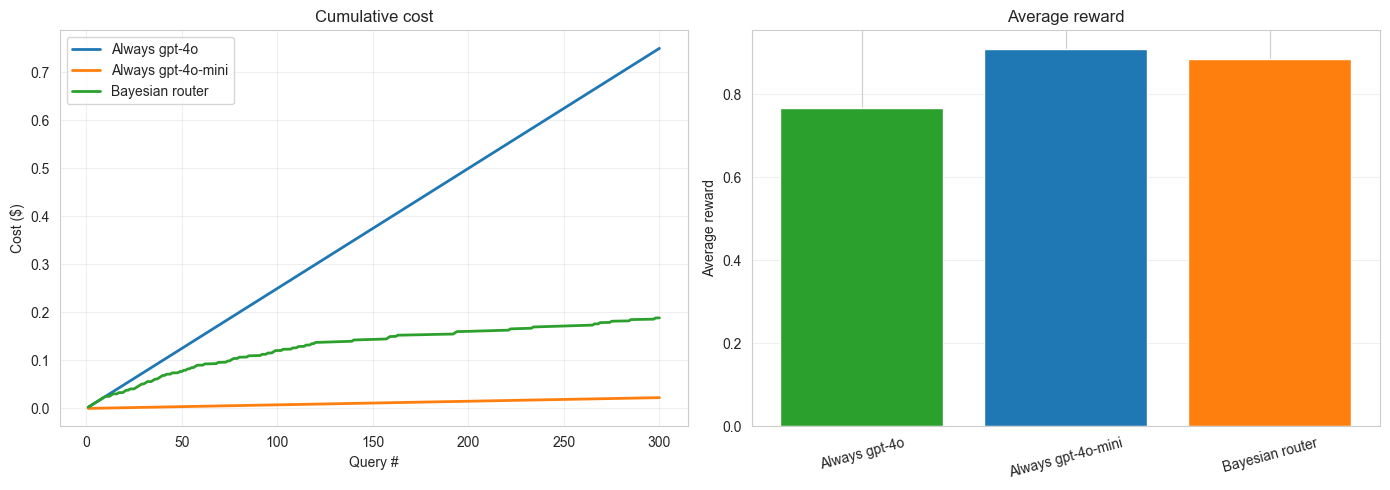


Router traffic allocation:

model        | traffic_share
-------------+--------------
gpt-4o       | 0.183        
gpt-4o-mini  | 0.417        
claude-haiku | 0.400        
Interpretation:
- Always gpt-4o is expensive but strong.
- Always gpt-4o-mini is cheap but weaker.
- The router learns a compromise: much cheaper than always strongest, better quality than always cheapest.


In [93]:
num_queries = 300

# Run 1: the full production router with all safety layers active.
# This is what the talk proposes as the practical solution.
_, router_records = run_router_simulation(
    priors=EXPERT_PRIORS,       # start with informed beliefs
    num_queries=num_queries,
    seed=31,
    gamma=0.95,                 # decay to handle provider drift
    confidence_floor=0.50,      # fallback if model confidence drops below 50%
    shadow_rate=0.05,           # 5% of requests silently evaluate a second model
    fallback_model="gpt-4o",    # trusted model to fall back to
)

# Run 2: dumb baseline — always use the most expensive model.
# Highest quality but highest cost. This is the "always-strongest" anti-pattern.
gpt4o_records = run_fixed_policy("gpt-4o", num_queries=num_queries, seed=31)

# Run 3: dumb baseline — always use the cheapest model.
# Lowest cost but weakest quality. This is the "always-cheapest" anti-pattern.
mini_records = run_fixed_policy("gpt-4o-mini", num_queries=num_queries, seed=31)

# Aggregate cost, reward, and latency for each policy.
# Note: router_records uses "total_cost" (primary + shadow cost).
#       fixed-policy records use "cost" (primary only, no shadow).
summary_rows = []
for label, records, cost_key in [
    ("Always gpt-4o",    gpt4o_records,   "cost"),
    ("Always gpt-4o-mini", mini_records,  "cost"),
    ("Bayesian router",  router_records,  "total_cost"),
]:
    total_cost = sum(row[cost_key] for row in records)
    avg_reward = average([row["reward_total"] for row in records])
    avg_latency = average([row["latency_ms"] for row in records])
    summary_rows.append(
        {
            "policy": label,
            "total_cost": total_cost,
            "avg_reward": avg_reward,
            "avg_latency_ms": avg_latency,
        }
    )

# Express router cost as a fraction of the "always gpt-4o" baseline.
# savings_vs_gpt4o = 1 - (router_cost / gpt4o_cost)
baseline_cost = next(row["total_cost"] for row in summary_rows if row["policy"] == "Always gpt-4o")
for row in summary_rows:
    row["cost_vs_gpt4o"] = row["total_cost"] / baseline_cost     # 1.0 = same cost as gpt-4o
    row["savings_vs_gpt4o"] = 1 - row["cost_vs_gpt4o"]           # positive = cheaper than gpt-4o

print("Policy comparison:\n")
print_table(summary_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([row["query_id"] for row in gpt4o_records], np.cumsum([row["cost"] for row in gpt4o_records]), linewidth=2, label="Always gpt-4o")
axes[0].plot([row["query_id"] for row in mini_records], np.cumsum([row["cost"] for row in mini_records]), linewidth=2, label="Always gpt-4o-mini")
axes[0].plot([row["query_id"] for row in router_records], np.cumsum([row["total_cost"] for row in router_records]), linewidth=2, label="Bayesian router")
axes[0].set_title("Cumulative cost")
axes[0].set_xlabel("Query #")
axes[0].set_ylabel("Cost ($)")
axes[0].legend()
axes[0].grid(alpha=0.3)

policy_names = [row["policy"] for row in summary_rows]
avg_rewards = [row["avg_reward"] for row in summary_rows]
axes[1].bar(policy_names, avg_rewards, color=["tab:green", "tab:blue", "tab:orange"])
axes[1].set_title("Average reward")
axes[1].set_ylabel("Average reward")
axes[1].grid(axis="y", alpha=0.3)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

router_model_rows = [
    {"model": model, "traffic_share": count / len(router_records)}
    for model, count in Counter(row["served_model"] for row in router_records).items()
]
print("\nRouter traffic allocation:\n")
print_table(router_model_rows)

print("Interpretation:")
print("- Always gpt-4o is expensive but strong.")
print("- Always gpt-4o-mini is cheap but weaker.")
print("- The router learns a compromise: much cheaper than always strongest, better quality than always cheapest.")

## Part 10: Contextual Routing as Future Work

The current router is **non-contextual**.
It learns one global belief per model.

That works well when:
- traffic is fairly homogeneous
- one model is just better on average
- the main issue is provider drift and online adaptation

Context becomes valuable when:
- short and long queries behave differently
- some models are stronger on code or structured tasks
- the best model depends on the query type

The simplest contextual extension is **discrete context**:
- classify the request as `short` or `long`
- keep separate `alpha` and `beta` values per `(model, context)` pair
- run Thompson Sampling inside that context bucket

The next cell shows a toy example where contextual routing clearly helps.

---
### 💬 Say this on stage — Part 10

> "Our current router is non-contextual. It learns one belief per model, shared across all query types. That works really well when providers drift over time. But there is a natural next step: what if short simple queries and long complex queries actually prefer different models? The answer is discrete contextual routing. You keep separate beliefs per model per context. The code change is surprisingly small — you just add a context key to the lookup table. And as this simulation shows, when the traffic is genuinely mixed, you can recover a meaningful improvement that the global router cannot see."

**Pointing at the plot:**
> "Look at the `long` bar on the right. The global router sends those queries to the model that wins overall, but on long queries that model is actually not the strongest. The contextual router figures that out and routes accordingly. That is the gain."

**Why the table and bar chart use the last 200 queries:**
> "I am showing the last 200 queries on purpose. Early in the run, Thompson Sampling is still exploring, so the raw selection counts include a lot of warm-up noise. The last 200 queries are a much better picture of the learned policy. That is where you can really see what each router settled on."

**If someone asks why claude-haiku still shows up early:**
> "That is normal. Early on, all models start from uniform priors, so they all get chances. The point of the last-200 view is to filter out that exploratory phase and focus on where the routers ended up after learning."

**Handling the follow-up question: 'Why not just always do contextual?':**
> "Because it multiplies data requirements. Each context bucket needs its own warm-up period. If your traffic is homogeneous, context adds complexity without benefit. You add it only when heterogeneity is measurable."

**One-sentence version for any Q&A card:**
> "Contextual routing is the natural evolution: instead of learning which model is best on average, we learn which model is best for each kind of query."

Toy contextual reward landscape:

context | gpt-4o | gpt-4o-mini | claude-haiku
--------+--------+-------------+-------------
short   | 0.720  | 0.900       | 0.840       
long    | 0.900  | 0.580       | 0.700       

Overall comparison:

router                       | avg_reward | avg_regret
-----------------------------+------------+-----------
Non-contextual Thompson      | 0.778      | 0.109     
Discrete contextual Thompson | 0.870      | 0.035     


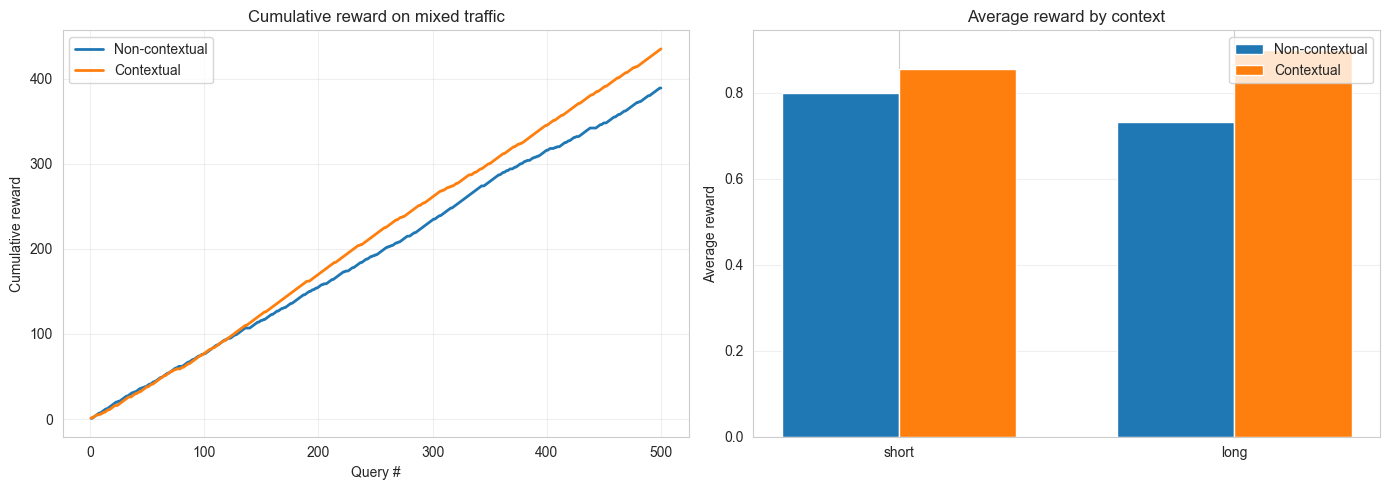


Which models get selected inside each context? (last 200 queries only)

context | model        | global_selected_count_last_200 | global_selected_share_last_200 | contextual_selected_count_last_200 | contextual_selected_share_last_200
--------+--------------+--------------------------------+--------------------------------+------------------------------------+-----------------------------------
short   | gpt-4o       | 13                             | 0.096                          | 7                                  | 0.051                             
short   | gpt-4o-mini  | 2                              | 0.015                          | 122                                | 0.897                             
short   | claude-haiku | 121                            | 0.890                          | 7                                  | 0.051                             
long    | gpt-4o       | 4                              | 0.062                          | 63                   

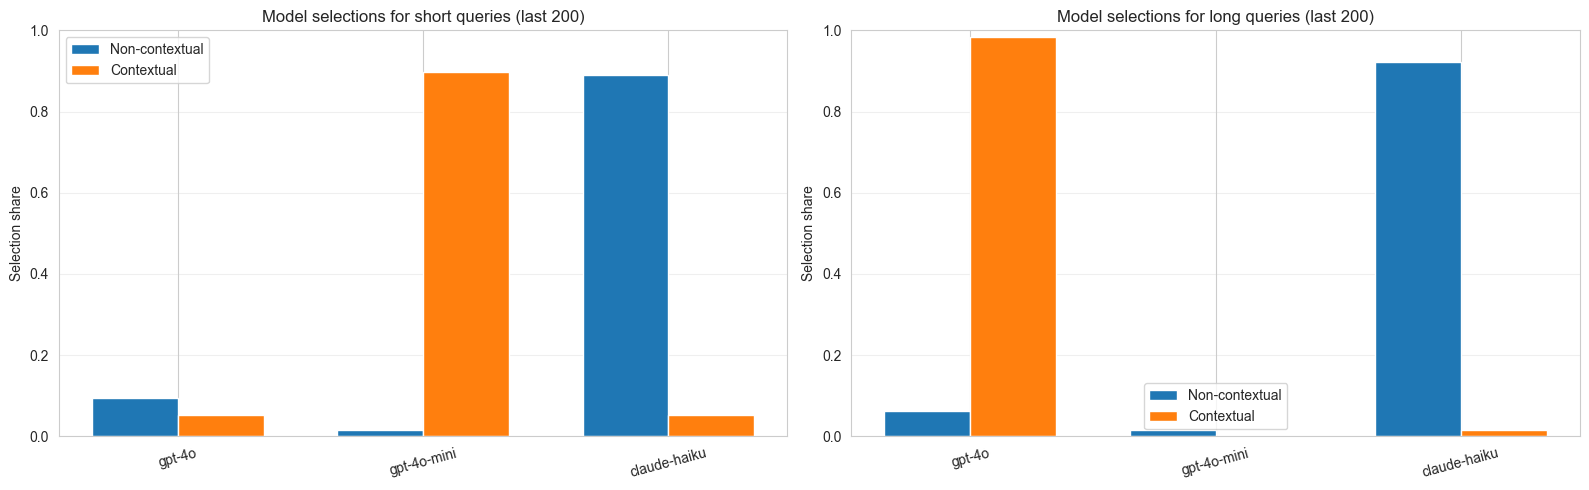

Intuition:
- A global router learns one average winner.
- A contextual router can learn different winners for different query types.
- Looking at the last 200 queries filters out much of the noisy warm-up exploration and shows the learned behavior more clearly.
- In that late window, the contextual router should lean toward gpt-4o-mini for short queries and toward gpt-4o for long queries.
- Discrete context is the simplest production path if traffic is heterogeneous.


In [94]:
# The "true" reward landscape in this toy scenario.
# gpt-4o-mini is better for short queries (0.90 vs 0.72).
# gpt-4o is better for long queries (0.90 vs 0.58).
# A global router learns the average and picks one model for all contexts.
# A contextual router keeps separate beliefs per (model, context) pair.
context_reward_rows = [
    {"context": "short", "gpt-4o": 0.72, "gpt-4o-mini": 0.90, "claude-haiku": 0.84},
    {"context": "long",  "gpt-4o": 0.90, "gpt-4o-mini": 0.58, "claude-haiku": 0.70},
]
print("Toy contextual reward landscape:\n")
print_table(context_reward_rows)


class GlobalThompsonRouter:
    """Non-contextual router: one belief per model, shared across all query types.
    This is exactly what the production router currently does.
    It ignores the context argument — context is passed in only for the reward lookup.
    """
    def __init__(self, models, alpha=1.0, beta=1.0):
        self.models = list(models)
        # Single (alpha, beta) per model — does not distinguish short vs long.
        self.alpha = {model: alpha for model in models}
        self.beta = {model: beta for model in models}

    def select(self, context):
        # Ignore context. Draw from the global belief for each model.
        samples = {model: np.random.beta(self.alpha[model], self.beta[model]) for model in self.models}
        return max(samples, key=samples.get)

    def update(self, context, model, reward):
        # Update global belief regardless of context.
        self.alpha[model] += reward
        self.beta[model] += 1 - reward


class DiscreteContextualThompsonRouter:
    """Contextual router: separate (alpha, beta) per (model, context) pair.
    This is the future-work extension.
    The code change is small: replace a 1D dict with a 2D dict keyed by (model, context).
    """
    def __init__(self, models, contexts, alpha=1.0, beta=1.0):
        self.models = list(models)
        self.contexts = list(contexts)
        # 2D belief table: (model, context) -> (alpha, beta)
        # Total entries = len(models) * len(contexts) = 3 * 2 = 6
        self.alpha = {(model, context): alpha for model in models for context in contexts}
        self.beta  = {(model, context): beta  for model in models for context in contexts}

    def select(self, context):
        # Thompson Sampling within the current context bucket only.
        # A model's global reputation does not spill over to a different context.
        samples = {
            model: np.random.beta(self.alpha[(model, context)], self.beta[(model, context)])
            for model in self.models
        }
        return max(samples, key=samples.get)

    def update(self, context, model, reward):
        # Update only the (model, context) slot, not all contexts for this model.
        self.alpha[(model, context)] += reward
        self.beta[ (model, context)] += 1 - reward


# True reward probabilities per (model, context).
context_profiles = {
    "short": {"gpt-4o": 0.72, "gpt-4o-mini": 0.90, "claude-haiku": 0.84},
    "long":  {"gpt-4o": 0.90, "gpt-4o-mini": 0.58, "claude-haiku": 0.70},
}
# Traffic mix: 65% of queries are "short", 35% are "long".
context_mix = {"short": 0.65, "long": 0.35}
models   = list(context_profiles["short"].keys())
contexts = list(context_profiles.keys())

random.seed(123)
np.random.seed(123)

# Both routers start from Beta(1,1) uniform priors.
global_router     = GlobalThompsonRouter(models)
contextual_router = DiscreteContextualThompsonRouter(models, contexts)
records = []

for query_id in range(1, 501):
    # Randomly pick a context for this request, weighted by the traffic mix.
    context = random.choices(list(context_mix.keys()), weights=list(context_mix.values()), k=1)[0]

    # --- Global router ---
    global_choice = global_router.select(context)    # ignores context
    # Simulate reward: 1.0 with probability context_profiles[context][global_choice]
    global_reward = 1.0 if random.random() < context_profiles[context][global_choice] else 0.0
    global_router.update(context, global_choice, global_reward)

    # --- Contextual router ---
    contextual_choice = contextual_router.select(context)    # uses context
    contextual_reward = 1.0 if random.random() < context_profiles[context][contextual_choice] else 0.0
    contextual_router.update(context, contextual_choice, contextual_reward)

    # best_possible = the reward you would get if you always picked the optimal model for this context
    best_possible = max(context_profiles[context].values())
    records.append(
        {
            "query_id": query_id,
            "context": context,
            "global_choice": global_choice,
            "global_reward": global_reward,
            "global_regret": best_possible - context_profiles[context][global_choice],   # 0 if optimal
            "contextual_choice": contextual_choice,
            "contextual_reward": contextual_reward,
            "contextual_regret": best_possible - context_profiles[context][contextual_choice],
        }
    )

summary_rows = [
    {
        "router": "Non-contextual Thompson",
        "avg_reward": average([row["global_reward"] for row in records]),
        "avg_regret": average([row["global_regret"] for row in records]),
    },
    {
        "router": "Discrete contextual Thompson",
        "avg_reward": average([row["contextual_reward"] for row in records]),
        "avg_regret": average([row["contextual_regret"] for row in records]),
    },
]
print("\nOverall comparison:\n")
print_table(summary_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([row["query_id"] for row in records], np.cumsum([row["global_reward"] for row in records]), linewidth=2, label="Non-contextual")
axes[0].plot([row["query_id"] for row in records], np.cumsum([row["contextual_reward"] for row in records]), linewidth=2, label="Contextual")
axes[0].set_title("Cumulative reward on mixed traffic")
axes[0].set_xlabel("Query #")
axes[0].set_ylabel("Cumulative reward")
axes[0].legend()
axes[0].grid(alpha=0.3)

# For selection-behavior analysis, focus on the last 200 queries only.
# This removes most of the early exploration noise and shows the learned policy more clearly.
late_records = records[-200:]

per_context_rows = []
per_context_choice_rows = []
for context in contexts:
    # Keep average reward by context over the full run.
    full_subset = [row for row in records if row["context"] == context]
    per_context_rows.append(
        {
            "context": context,
            "global_avg_reward": average([row["global_reward"] for row in full_subset]),
            "contextual_avg_reward": average([row["contextual_reward"] for row in full_subset]),
        }
    )

    # But count actual model selections only in the last 200 queries.
    # This better represents what each router has learned after warm-up.
    late_subset = [row for row in late_records if row["context"] == context]
    global_counts = Counter(row["global_choice"] for row in late_subset)
    contextual_counts = Counter(row["contextual_choice"] for row in late_subset)
    total = len(late_subset)
    for model in models:
        per_context_choice_rows.append(
            {
                "context": context,
                "model": model,
                "global_selected_count_last_200": global_counts.get(model, 0),
                "global_selected_share_last_200": global_counts.get(model, 0) / total,
                "contextual_selected_count_last_200": contextual_counts.get(model, 0),
                "contextual_selected_share_last_200": contextual_counts.get(model, 0) / total,
            }
        )

x = np.arange(len(contexts))
width = 0.35
axes[1].bar(x - width / 2, [row["global_avg_reward"] for row in per_context_rows], width, label="Non-contextual")
axes[1].bar(x + width / 2, [row["contextual_avg_reward"] for row in per_context_rows], width, label="Contextual")
axes[1].set_xticks(x)
axes[1].set_xticklabels(contexts)
axes[1].set_ylabel("Average reward")
axes[1].set_title("Average reward by context")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nWhich models get selected inside each context? (last 200 queries only)\n")
print_table(per_context_choice_rows)

# Make the learned selection behavior visual too.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, context in zip(axes, contexts):
    context_rows = [row for row in per_context_choice_rows if row["context"] == context]
    local_x = np.arange(len(models))
    ax.bar(
        local_x - width / 2,
        [row["global_selected_share_last_200"] for row in context_rows],
        width,
        label="Non-contextual",
    )
    ax.bar(
        local_x + width / 2,
        [row["contextual_selected_share_last_200"] for row in context_rows],
        width,
        label="Contextual",
    )
    ax.set_xticks(local_x)
    ax.set_xticklabels(models, rotation=15)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Selection share")
    ax.set_title(f"Model selections for {context} queries (last 200)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("Intuition:")
print("- A global router learns one average winner.")
print("- A contextual router can learn different winners for different query types.")
print("- Looking at the last 200 queries filters out much of the noisy warm-up exploration and shows the learned behavior more clearly.")
print("- In that late window, the contextual router should lean toward gpt-4o-mini for short queries and toward gpt-4o for long queries.")
print("- Discrete context is the simplest production path if traffic is heterogeneous.")

## Final Summary: The Full End-to-End Flow

If you can explain the following sequence smoothly, you understand the talk:

1. We have a cost problem because always using the strongest model is expensive.
2. We cannot depend on human labels in production.
3. So we build a composite reward from validity, latency, and retry behavior.
4. The router keeps one Beta belief per model.
5. Thompson Sampling draws one sample from each belief and picks the winner.
6. The chosen model returns telemetry.
7. That telemetry becomes a reward in `[0, 1]`.
8. `alpha` increases by the reward, `beta` increases by `1 - reward`.
9. Expert priors make the first few queries less wasteful.
10. Decay prevents stale history from dominating forever.
11. Fallback, shadow evaluation, and circuit breakers make the system safer.
12. Over time, the router shifts traffic toward the best cost/quality tradeoff.
13. If query types differ a lot, contextual routing is the natural next step.

## A good study sequence after this notebook

1. run this notebook from top to bottom
2. read `model_routing/docs/devconf_model_routing_talk_guide.md`
3. review `model_routing/bayesian_router/router.py` only after the intuition feels solid
4. use `model_routing/docs/bayesian_bandits_study_material.md` and `..._COMPLETE.md` for deeper Q&A prep

## One-sentence version for the talk

Instead of sending every request to the most expensive model, we can use a Bayesian router that learns from production telemetry such as validity, latency, and retries, and gradually shifts traffic to cheaper models when it is safe to do so.